# СберАвтоПодписка

## Подготовка данных

### Табличка ga_hits с информацией по событиям внутри сессий

In [2]:
import pandas as pd
import numpy as np

In [3]:
df_ga = pd.read_pickle('ga_hits.pkl')

In [4]:
df_ga.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15726470 entries, 0 to 15726469
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   session_id      object 
 1   hit_date        object 
 2   hit_time        float64
 3   hit_number      int64  
 4   hit_type        object 
 5   hit_referer     object 
 6   hit_page_path   object 
 7   event_category  object 
 8   event_action    object 
 9   event_label     object 
 10  event_value     object 
dtypes: float64(1), int64(1), object(9)
memory usage: 1.3+ GB


In [5]:
df_ga['session_id'] = pd.util.hash_pandas_object(df_ga['session_id'], index=False)

#### Пропуски

Посмотрим на пропуски в данных

In [6]:
(df_ga.isna()*1).describe()

,session_id,hit_date,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label,event_value
count,15726470.0,15726470.0,1.572647e+07,15726470.0,15726470.0,1.572647e+07,15726470.0,15726470.0,15726470.0,1.572647e+07,15726470.0
mean,0.0,0.0,5.824779e-01,0.0,0.0,3.989963e-01,0.0,0.0,0.0,2.390990e-01,1.0
std,0.0,0.0,4.931505e-01,0.0,0.0,4.896920e-01,0.0,0.0,0.0,4.265334e-01,0.0
min,0.0,0.0,0.000000e+00,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.000000e+00,1.0
25%,0.0,0.0,0.000000e+00,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.000000e+00,1.0
50%,0.0,0.0,1.000000e+00,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.000000e+00,1.0
75%,0.0,0.0,1.000000e+00,0.0,0.0,1.000000e+00,0.0,0.0,0.0,0.000000e+00,1.0
max,0.0,0.0,1.000000e+00,0.0,0.0,1.000000e+00,0.0,0.0,0.0,1.000000e+00,1.0


Колонка event_value пустая целиком - удалим ее

In [7]:
df_ga.drop(columns = ['event_value'], inplace = True)

In [8]:
df_ga.head(20)

,session_id,hit_date,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label
0,4527919704133333375,2021-12-23,597864.0,30,event,NaN,sberauto.com/cars?utm_source_initial=google&ut...,quiz,quiz_show,NaN
1,11086678017974654131,2021-12-23,597331.0,41,event,NaN,sberauto.com/cars/fiat?city=1&city=18&rental_c...,quiz,quiz_show,NaN
2,15937732922909383459,2021-12-23,796252.0,49,event,NaN,sberauto.com/cars/all/volkswagen/polo/e994838f...,quiz,quiz_show,NaN
3,6320098656570001991,2021-12-23,934292.0,46,event,NaN,sberauto.com/cars?utm_source_initial=yandex&ut...,quiz,quiz_show,NaN
4,2626200937397613665,2021-12-23,768741.0,79,event,NaN,sberauto.com/cars/all/mercedes-benz/cla-klasse...,quiz,quiz_show,NaN
5,1138728206641189523,2021-12-23,704194.0,41,event,NaN,sberauto.com/cars?utm_source_initial=youtube&u...,quiz,quiz_show,NaN
6,1670654597424237638,2021-12-23,911854.0,102,event,NaN,sberauto.com/cars/toyota?isnew=false&rental_ca...,quiz,quiz_show,NaN
7,84454111960797062,2021-12-23,1071804.0,85,event,NaN,sberauto.com/cars/all/mercedes-benz/glc/f8f330...,quiz,quiz_show,NaN
8,11176801392621454029,2021-12-23,1013899.0,101,event,VloVXNWduHeTjUoDkjkO,sberauto.com/cars/all/kia/sorento/c38179cb?utm...,quiz,quiz_show,NaN
9,15841386919363063385,2021-12-23,0.0,1,event,NaN,sberauto.com/cars/all/nissan/x-trail/0744675f?...,card_web,view_card,NaN


Проверим пропуски в hit_time - они не заполняются только внутри отдлеьных сессий или есть сессии, где таже потеряна лишь часть данных о времени hit

In [9]:
df_ga['hit_time_isna'] = df_ga['hit_time'].isna()

In [10]:
session_nans = df_ga.groupby(['session_id']).agg({'hit_time_isna':'mean',
                                            'hit_number':('nunique', 'count')})

In [11]:
session_nans.columns = ['hit_time_isna_mean', 'hit_number_unique', 'hit_number_count']

Видим, что есть только сессии где нет совсем заполненнфх hit_time (все значения пустые), все значения непустые, ровно половина значений непустые

In [12]:
session_nans['hit_time_isna_mean'].value_counts()

hit_time_isna_mean
1.0    998929
0.0    705527
0.5     30154
Name: count, dtype: int64

Хочется понять природу этих пропусков, возможно они возникают лишь при дубликации данных

In [13]:
session_nans.reset_index().query('hit_time_isna_mean == 0.5')

,session_id,hit_time_isna_mean,hit_number_unique,hit_number_count
51,601097190607276,0.5,12,24
71,833552104729776,0.5,9,18
192,2064499293518347,0.5,6,12
259,2859238972701019,0.5,7,14
336,3599802429818094,0.5,28,56
...,...,...,...,...
1734017,18440163472617705535,0.5,2,4
1734079,18440954680302412769,0.5,1,2
1734328,18443837850715052847,0.5,2,4
1734356,18444070375148249149,0.5,1,2


In [14]:
session_nans.reset_index().query('hit_number_unique != hit_number_count')['hit_time_isna_mean'].value_counts()

hit_time_isna_mean
0.5    30154
Name: count, dtype: int64

In [15]:
df_ga.shape

(15726470, 11)

- По видимому в таких сессиях ровно пололвина событий обладает неуникальными hit_number в которых одна половина заполняется NaN а другая настоящими значениями 
- Можем  дропнуть NaN по принципу того, что hit_time_isna = True и при этом внутри сессии 50% событий это дубликаты

In [16]:
df_ga_f = df_ga[~df_ga['session_id'].isin(session_nans.reset_index().query('hit_time_isna_mean == 0.5')['session_id'])]

In [17]:
df_ga_f.shape

(15274746, 11)

In [18]:
(df_ga_f.isna()*1).describe()

,session_id,hit_date,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label,hit_time_isna
count,15274746.0,15274746.0,1.527475e+07,15274746.0,15274746.0,1.527475e+07,15274746.0,15274746.0,15274746.0,1.527475e+07,15274746.0
mean,0.0,0.0,5.849171e-01,0.0,0.0,3.969985e-01,0.0,0.0,0.0,2.338550e-01,0.0
std,0.0,0.0,4.927363e-01,0.0,0.0,4.892757e-01,0.0,0.0,0.0,4.232811e-01,0.0
min,0.0,0.0,0.000000e+00,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.0
25%,0.0,0.0,0.000000e+00,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.0
50%,0.0,0.0,1.000000e+00,0.0,0.0,0.000000e+00,0.0,0.0,0.0,0.000000e+00,0.0
75%,0.0,0.0,1.000000e+00,0.0,0.0,1.000000e+00,0.0,0.0,0.0,0.000000e+00,0.0
max,0.0,0.0,1.000000e+00,0.0,0.0,1.000000e+00,0.0,0.0,0.0,1.000000e+00,0.0


In [19]:
df_ga_f['event_label'] = df_ga_f['event_label'].fillna('unknown_event_label')

/var/folders/4z/h8k7zvsj0x1864msx6kfvky80000gn/T/ipykernel_68111/451034536.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ga_f['event_label'] = df_ga_f['event_label'].fillna('unknown_event_label')


In [20]:
df_ga_f['hit_referer'] = df_ga_f['hit_referer'].fillna('unknown_hit_referer')

/var/folders/4z/h8k7zvsj0x1864msx6kfvky80000gn/T/ipykernel_68111/2922493426.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ga_f['hit_referer'] = df_ga_f['hit_referer'].fillna('unknown_hit_referer')


#### Посмотрим на то что содержится в датасете
- event_category - категория пользовательского действия (сценарий использования продукта)
- event_action - конкретное действие внутри сценария

In [21]:
df_ga_f['event_category'].value_counts()

event_category
card_web                         7139330
search_form                      2397179
sub_page_view                    1947954
sub_button_click                 1051103
listing_ads                      1017530
cars                              358871
sap_search_form                   353718
quiz                              256284
sap_search__form                  186943
auth                              183869
jivosite                           88443
chat                               82485
ad_banner                          38791
offers                             31218
navigation                         25463
footer                             19651
sub_submit                         18111
greenday_sub_button_click          15425
main_banners                       14142
profile_menu                       13425
scrolling_main_page                11882
active_invitation                   8478
header                              3531
my_idea                             2255
g

In [22]:
df_ga_f[['event_category', 'event_action']].value_counts().reset_index().to_csv('data_event_action.csv')

Попытаемся выделить основные продуктивные сценарии которые можно считать "конверсией" в целевое действие
- target_submits - прямые заявки на аренду авто
- target_contacts - заявки на связь с менеджером
- target_auth - успешная авторизация внутри сервиса
- target_chat - успешное инициирование общения в чате на стороне пользователя

В результате получим полный список TARGET_EVENTS который описывает все действия пользователя которые мы будем расценивать как целвые и считать по ним конверсию

In [23]:
target_submits = [
    'sub_submit_success', 
    'sub_car_claim_submit_click', 
    'sub_callback_submit_click', 
    'sub_car_request_submit_click',
    'greenday_sub_submit_success', 
    'greenday_sub_callback_submit_click', 
    'sub_custom_question_submit_click', 
    'form_request_call_sent'
]

target_contacts = [
    'sub_call_number_click', 
    'greenday_sub_call_number_click',
    'tap_on_phone_800', 
    'tap_on_phone_495',
    'user gave contacts during chat', 
    'callback requested', 
    'jivo_telegram', 'jivo_viber', 
    'jivo_vkontakte', 'jivo_facebook'
]

target_auth = [
    'phone_auth_success', 
    'sber_id_auth_success', 
    'code_sms_entered_success', 
    'phone_entered', 
    'name_entered', 
    'surname_entered', 
    'patronymic_entered',
    'phone_entered_on_form_request_call',
    'name_entered_on_form_request_call'
]

target_chat = [
    'start_chat', 
    'sub_open_dialog_click', 
    'greenday_sub_open_dialog_click',
    'click_on_start_chatting', 
    'chat established',
    'client initiate chat'
]

TARGET_EVENTS = target_submits + target_contacts + target_auth + target_chat

In [24]:
df_ga_f['has_target_action'] = df_ga_f['event_action'].isin(TARGET_EVENTS)*1

/var/folders/4z/h8k7zvsj0x1864msx6kfvky80000gn/T/ipykernel_68111/1947066386.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ga_f['has_target_action'] = df_ga_f['event_action'].isin(TARGET_EVENTS)*1


In [25]:
df_ga_f.sort_values(by = ['session_id', 'hit_number'], ascending = True, inplace = True)

/var/folders/4z/h8k7zvsj0x1864msx6kfvky80000gn/T/ipykernel_68111/1257707102.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ga_f.sort_values(by = ['session_id', 'hit_number'], ascending = True, inplace = True)


In [26]:
df_ga_f.head(20)

,session_id,hit_date,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label,hit_time_isna,has_target_action
3053873,6756988320252,2021-12-21,1876.0,2,event,unknown_hit_referer,podpiska.sberauto.com/,sub_page_view,sub_landing,unknown_event_label,False,0
10450164,11533293729765,2021-11-01,384.0,3,event,unknown_hit_referer,podpiska.sberauto.com/,sub_page_view,sub_landing,unknown_event_label,False,0
10001963,11533293729765,2021-11-01,3864.0,4,event,unknown_hit_referer,podpiska.sberauto.com/,sub_button_click,sub_offer_click,VppGBKuEPJVLSsOLERbm,False,0
13153679,11533293729765,2021-11-01,3865.0,5,event,unknown_hit_referer,podpiska.sberauto.com/,offers,open_offer,unknown_event_label,False,0
14057667,11533293729765,2021-11-01,5380.0,6,event,unknown_hit_referer,podpiska.sberauto.com/,sub_button_click,sub_offer_click,hIzqhvjpcwCLzzTVHCuE,False,0
11351333,11533293729765,2021-11-01,5381.0,7,event,unknown_hit_referer,podpiska.sberauto.com/,offers,open_offer,unknown_event_label,False,0
13156547,11533293729765,2021-11-01,8370.0,8,event,unknown_hit_referer,podpiska.sberauto.com/,sub_button_click,sub_offer_click,yatapsJsSVhXEatMiuad,False,0
12252543,11533293729765,2021-11-01,8372.0,9,event,unknown_hit_referer,podpiska.sberauto.com/,offers,go_to_offer,unknown_event_label,False,0
14017992,42337482256685,2021-10-13,NaN,3,event,HbolMJUevblAbkHClEQa,sberauto.com/cars?city=1&city=18&rental_car=re...,search_form,search_form_search_car_type_select,UhNimfrZlNAYRFfFUeiH,True,0
14017772,42337482256685,2021-10-13,NaN,4,event,HbolMJUevblAbkHClEQa,sberauto.com/cars?city=1&city=18&rental_car=re...,listing_ads,go_to_car_card,hAHqGICPFQiPwtzubOzs,True,0


Создадим также вспомогательные категории пользовательского поведения:
- behavior_exploration - просмотр карточек автомобилей - ифнормации, фотографий, цены
- behavior_filtering - поиск/фильтрация в поиске
- behavior_engagement - энгейджмент с предложением о покупке/конкурентных преимуществах
- behavior_funnel_entry - переход в воронку для получения предложения (общение с менеджером, аутентификация в сервисе)
- behavior_promo - взаимодействие с промо акциями и предложениями

Обращу внимание на подбор прокси пользовательского поведения в сервисе. Их нужно подобрать так чтобы прокси не слишком сильно кореллировало с has_target_action (наша конверсия), иначе в финальной модели признак поглотит всю предсказательную силу, а результате модели получатся не ифнормативными. Для этого уберем из потенциальных прокси все признаки, после которых происходит любой из событий has_target_action в 50% случаев и более (из частотных сценариев которые наблюдались внутри > 1000 пользовательских сессий)

In [27]:
df_ga_f['has_target_action_by_now'] = df_ga_f.groupby('session_id')['has_target_action'].cummax()

/var/folders/4z/h8k7zvsj0x1864msx6kfvky80000gn/T/ipykernel_68111/2644746047.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ga_f['has_target_action_by_now'] = df_ga_f.groupby('session_id')['has_target_action'].cummax()


In [28]:
df_ga_f['has_target_action_by_now'] = df_ga_f['has_target_action_by_now']*(df_ga_f['has_target_action'] != 1)

/var/folders/4z/h8k7zvsj0x1864msx6kfvky80000gn/T/ipykernel_68111/2893740085.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ga_f['has_target_action_by_now'] = df_ga_f['has_target_action_by_now']*(df_ga_f['has_target_action'] != 1)


In [29]:
events_after_target = df_ga_f.groupby(['event_action'], as_index = False).agg({'session_id':'count',
                                                         'has_target_action_by_now':'sum'})

In [30]:
events_after_target['rate_after_target'] = events_after_target['has_target_action_by_now']/events_after_target['session_id']

In [31]:
events_after_target.sort_values(by = ['rate_after_target'], ascending = False).query('rate_after_target > 0.5 & session_id > 1000')

,event_action,session_id,has_target_action_by_now,rate_after_target
3,automatic_return_to_chat,2667,2661,0.997750
57,click_skip_form_lets_get_acquainted,1595,1583,0.992476
185,show_sms_code_input,12814,12656,0.987670
33,click_on_confirm_sms_code,12679,12517,0.987223
38,click_on_get_code,13374,13143,0.982728
2,auto_subscription_click,5939,5808,0.977942
224,user_message,4347,4247,0.976996
222,typing_in_leasing_chat,5597,5461,0.975701
179,show_form_lets_get_acquainted,7181,6909,0.962122
43,click_on_my_data,3281,2708,0.825358


Теперь можем скомпоновать признаки будучи уверенными в том, что они не идеально скореллированы с таргетом

In [32]:
behavior_exploration = [
    'view_card', 'view_new_card', 'view_used_card', 'go_to_car_card', 'sub_car_page',
    'pagination_click', 'sub_view_cars_click', 'showed_number_ads', 'listing_ads_sort', 
    'view_more_click', 'photos_all', 'photos', 'sub_landing', 'sub_header_link_click', 
    'sub_footer_link_click', 'click_on_menu', 'click_on_logo',
    'go_to_offer', 
    'open_offer',
    'sub_account_page'
]
behavior_filtering = [
    'search_form_search_btn', 'search_form_region', 'search_form_clear',
    'sap_search_form_cost_to', 'sap_search_form_cost_from', 'search_form_cost_to', 
    'search_form_cost_from', 'search_form_rental', 'search_form_mark_select', 
    'search_form_mark_multiselect', 'search_form_model_select', 'search_form_model_multiselec', 
    'search_form_search_car_type_select', 'search_form_modification_select', 'search_body_type', 
    'search_kpp', 'search_form_year_from', 'search_form_year_to', 'search_km_from', 
    'search_km_to', 'search_engine', 'search_drive', 'search_power_from', 
    'search_power_to', 'search_steering_wheel', 'search_color'
]
behavior_engagement = [
    'sub_faq', 'sub_view_faq_click', 'scrolling_to_services', 'scrolling_to_advantages', 
    'go_to_terms', 'go_to_privacy_partners', 'quiz_show', 'quiz_start'
]
behavior_funnel_entry = [
    'start_auth', 'phone_auth_start', 'sber_id_auth_start', 'show_phone_input', 
    'proactive invitation shown', 
    'showed_active_invitation', 'proactive invitation rejected',
    'chat requested'
]
behavior_promo = [
    'greenday_get_gift', 'greenday_sub_view_cars_click', 'greenday_go_to_car_card', 
    'greenday_get_discount', 'toggle_leasing_cars_show', 'go_to_special_offers', 
    'click_car_buyback', 'go_to_job', 'go_to_my_idea'
]

In [33]:
events_after_target[events_after_target['event_action'].isin(behavior_exploration + behavior_filtering + behavior_engagement + behavior_funnel_entry + behavior_promo)].sort_values(by = 'rate_after_target')

,event_action,session_id,has_target_action_by_now,rate_after_target
206,sub_landing,1761273,23016,0.013068
211,sub_view_cars_click,776767,12834,0.016522
226,view_more_click,109951,1980,0.018008
138,sap_search_form_cost_to,353718,7334,0.020734
186,showed_active_invitation,8237,187,0.022702
...,...,...,...,...
191,start_auth,38113,14144,0.371107
119,phone_auth_start,1619,628,0.387894
180,show_phone_input,30869,12178,0.394506
143,sber_id_auth_start,4973,2168,0.435954


In [34]:
df_ga_f['has_behavior_exploration'] = df_ga_f['event_action'].isin(behavior_exploration)*1
df_ga_f['has_behavior_filtering'] = df_ga_f['event_action'].isin(behavior_filtering)*1
df_ga_f['has_behavior_engagement'] = df_ga_f['event_action'].isin(behavior_engagement)*1
df_ga_f['has_behavior_funnel_entry'] = df_ga_f['event_action'].isin(behavior_funnel_entry)*1
df_ga_f['has_behavior_promo'] = df_ga_f['event_action'].isin(behavior_promo)*1

/var/folders/4z/h8k7zvsj0x1864msx6kfvky80000gn/T/ipykernel_68111/1591272833.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ga_f['has_behavior_exploration'] = df_ga_f['event_action'].isin(behavior_exploration)*1
/var/folders/4z/h8k7zvsj0x1864msx6kfvky80000gn/T/ipykernel_68111/1591272833.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ga_f['has_behavior_filtering'] = df_ga_f['event_action'].isin(behavior_filtering)*1
/var/folders/4z/h8k7zvsj0x1864msx6kfvky80000gn/T/ipykernel_68111/1591272833.py

In [35]:
df_ga_f.head(20)

,session_id,hit_date,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label,hit_time_isna,has_target_action,has_target_action_by_now,has_behavior_exploration,has_behavior_filtering,has_behavior_engagement,has_behavior_funnel_entry,has_behavior_promo
3053873,6756988320252,2021-12-21,1876.0,2,event,unknown_hit_referer,podpiska.sberauto.com/,sub_page_view,sub_landing,unknown_event_label,False,0,0,1,0,0,0,0
10450164,11533293729765,2021-11-01,384.0,3,event,unknown_hit_referer,podpiska.sberauto.com/,sub_page_view,sub_landing,unknown_event_label,False,0,0,1,0,0,0,0
10001963,11533293729765,2021-11-01,3864.0,4,event,unknown_hit_referer,podpiska.sberauto.com/,sub_button_click,sub_offer_click,VppGBKuEPJVLSsOLERbm,False,0,0,0,0,0,0,0
13153679,11533293729765,2021-11-01,3865.0,5,event,unknown_hit_referer,podpiska.sberauto.com/,offers,open_offer,unknown_event_label,False,0,0,1,0,0,0,0
14057667,11533293729765,2021-11-01,5380.0,6,event,unknown_hit_referer,podpiska.sberauto.com/,sub_button_click,sub_offer_click,hIzqhvjpcwCLzzTVHCuE,False,0,0,0,0,0,0,0
11351333,11533293729765,2021-11-01,5381.0,7,event,unknown_hit_referer,podpiska.sberauto.com/,offers,open_offer,unknown_event_label,False,0,0,1,0,0,0,0
13156547,11533293729765,2021-11-01,8370.0,8,event,unknown_hit_referer,podpiska.sberauto.com/,sub_button_click,sub_offer_click,yatapsJsSVhXEatMiuad,False,0,0,0,0,0,0,0
12252543,11533293729765,2021-11-01,8372.0,9,event,unknown_hit_referer,podpiska.sberauto.com/,offers,go_to_offer,unknown_event_label,False,0,0,1,0,0,0,0
14017992,42337482256685,2021-10-13,NaN,3,event,HbolMJUevblAbkHClEQa,sberauto.com/cars?city=1&city=18&rental_car=re...,search_form,search_form_search_car_type_select,UhNimfrZlNAYRFfFUeiH,True,0,0,0,1,0,0,0
14017772,42337482256685,2021-10-13,NaN,4,event,HbolMJUevblAbkHClEQa,sberauto.com/cars?city=1&city=18&rental_car=re...,listing_ads,go_to_car_card,hAHqGICPFQiPwtzubOzs,True,0,0,1,0,0,0,0


### Формируем таблицу с аггрегированной информацией поведения пользователя внутри сессии

In [36]:
target_action_sesh = df_ga_f.groupby(['session_id'], as_index = False).agg({'has_target_action':'max',
                                                                            'hit_number':'max', 
                                                                            'hit_time': ('min', 'max'),
                                                                           'has_behavior_exploration': ('max', 'sum'),
                                                                           'has_behavior_filtering': ('max', 'sum'),
                                                                           'has_behavior_engagement': ('max', 'sum'),
                                                                           'has_behavior_funnel_entry': ('max', 'sum'),
                                                                           'has_behavior_promo': ('max', 'sum')})

In [37]:
target_action_sesh.columns = ['session_id', 'has_target_action', 'hit_number_max',
                             'hit_time_min', 'hit_time_max',
                             'has_behavior_exploration', 'qty_behavior_exploration',
                             'has_behavior_filtering', 'qty_behavior_filtering',
                             'has_behavior_engagement', 'qty_behavior_engagement',
                             'has_behavior_funnel_entry', 'qty_behavior_funnel_entry',
                             'has_behavior_promo', 'qty_behavior_promo']

In [38]:
target_action_sesh['session_length'] = target_action_sesh['hit_time_max'] - target_action_sesh['hit_time_min']

In [39]:
target_action_sesh.drop(columns = ['hit_time_min', 'hit_time_max'], inplace = True)

In [40]:
target_action_sesh[['qty_behavior_exploration',
       'qty_behavior_filtering',
        'qty_behavior_engagement',
        'qty_behavior_funnel_entry',
       'qty_behavior_promo', 'has_target_action']].corr()

,qty_behavior_exploration,qty_behavior_filtering,qty_behavior_engagement,qty_behavior_funnel_entry,qty_behavior_promo,has_target_action
qty_behavior_exploration,1.000000,0.163822,0.262329,0.151476,0.061746,0.157640
qty_behavior_filtering,0.163822,1.000000,0.143924,0.075130,0.196084,0.079038
qty_behavior_engagement,0.262329,0.143924,1.000000,0.097923,0.034055,0.111480
qty_behavior_funnel_entry,0.151476,0.075130,0.097923,1.000000,0.057268,0.279444
qty_behavior_promo,0.061746,0.196084,0.034055,0.057268,1.000000,0.053756
has_target_action,0.157640,0.079038,0.111480,0.279444,0.053756,1.000000


## Игры с hit_path
В адресах ссылок есть ценные указатели - например названия марок автомобилей и их моделей. Если мы их спарсим и получим признаки на посещение лендинга/карточки опредеелнной марки, то мы сможем значительно повысить точность предсказаний и обогатить информацию о пользовательских сессиях

In [41]:
import re

def is_valid_string(text):
    pattern = r'^[a-z._]+$'
    return bool(re.fullmatch(pattern, text))
def extract_qualities_page_path(x_str, dict_to_df = False):
    if x_str is np.nan:
        return {}
    else:
        list_x = x_str.split('/')
        list_x = [xs for xs in list_x if xs != '']
        if len(list_x) == 1:
            # return {'domain': list_x[0]}
            keys_x = list_x
            vals_x = [1]*len(list_x)
            dict_x = dict(zip(keys_x, vals_x))
        else:
            keys_x = []
            vals_x = [] 
            for idx, l in enumerate(list_x):
                # list_xl.append(
                vals_l = re.split(r'[&?]', l)
                for val in vals_l:
                    val_eq = val.split('=')
                    if len(val_eq) != 1:
                        keys_x.append(val_eq[0])
                        vals_x.append(val_eq[1])
                    else:
                        keys_x.append(val_eq[0])
                        vals_x.append(1)
        dict_x = dict(zip(keys_x, vals_x))
        
    if dict_to_df is True:
        return pd.DataFrame.from_dict(dict_x, orient = 'index').T
    else:
        return dict_x

In [42]:
df_ga_f['hit_page_path'].iloc[0]

'podpiska.sberauto.com/'

In [43]:
extract_qualities_page_path(df_ga_f['hit_page_path'].iloc[1000])

{'sberauto.com': 1,
 'cars': 1,
 'all': 1,
 'renault': 1,
 'duster': 1,
 '145d53f1': 1,
 'rental_page': 'rental_car'}

In [44]:
df_ga_f.shape

(15274746, 18)

In [292]:
distinct_attributes_path = pd.DataFrame([])
for i in range(0, df_ga_f.shape[0], 250000):
    print(f'Process from {i}')
    df_path_batch = pd.DataFrame(pd.json_normalize(np.vectorize(extract_qualities_page_path)(df_ga_f.iloc[i : i + 250000]['hit_page_path'])).columns)
    distinct_attributes_path = pd.concat([distinct_attributes_path, df_path_batch], axis = 0)

Process from 0
Process from 250000
Process from 500000
Process from 750000
Process from 1000000
Process from 1250000
Process from 1500000
Process from 1750000
Process from 2000000
Process from 2250000
Process from 2500000
Process from 2750000
Process from 3000000
Process from 3250000
Process from 3500000
Process from 3750000
Process from 4000000
Process from 4250000
Process from 4500000
Process from 4750000
Process from 5000000
Process from 5250000
Process from 5500000
Process from 5750000
Process from 6000000
Process from 6250000
Process from 6500000
Process from 6750000
Process from 7000000
Process from 7250000
Process from 7500000
Process from 7750000
Process from 8000000
Process from 8250000
Process from 8500000
Process from 8750000
Process from 9000000
Process from 9250000
Process from 9500000
Process from 9750000
Process from 10000000
Process from 10250000
Process from 10500000
Process from 10750000
Process from 11000000
Process from 11250000
Process from 11500000
Process from 11

In [294]:
distinct_attributes_path.drop_duplicates().shape

(4681, 1)

In [295]:
distinct_attributes_path.head(20)

,0
0,sberauto.com
1,cars
2,utm_source_initial
3,utm_medium_initial
4,utm_campaign_initial
5,utm_content_initial
6,utm_term_initial
7,city
8,rental_page
9,rental_car


Попросим нейросетку по csv файлу на ~4 тыс entries сформировать список найденных в ней марок + моделей

In [41]:
distinct_attributes_path.drop_duplicates().to_csv('car_models.csv')

In [45]:
df_brand_and_models = pd.read_csv('car_brands_and_models.csv', sep = ';')

In [46]:
df_brand_and_models['car_brand'].unique()

array(['acura', 'audi', 'bentley', 'bmw', 'brilliance', 'cadillac',
       'chery', 'cheryexeed', 'chevrolet', 'daihatsu', 'dodge', 'fiat',
       'ford', 'gaz', 'geely', 'genesis', 'haval', 'honda', 'hyundai',
       'infiniti', 'jac', 'jaguar', 'jeep', 'kia', 'lada-vaz',
       'lamborghini', 'land-rover', 'lexus', 'lifan', 'mazda',
       'mercedes-benz', 'mini', 'mitsubishi', 'nissan', 'peugeot',
       'porsche', 'renault', 'skoda', 'tesla', 'toyota', 'uaz',
       'volkswagen', 'volvo'], dtype=object)

In [47]:
df_brand_and_models['car_model_brand'] = (df_brand_and_models['car_brand'] + '/' + df_brand_and_models['car_model']).astype(str)

Получили датасет со всеми марками автомобилей и моделями встречающимися в ссылках hit_page_path
Теперь с помощью модуля ahocorasick можем по заданной строке hit_page_path найти какие из значений в таблице df_brand_and_models встречались в ней и опреедлить страницу с каким автомобилем просматривал пользователь

In [48]:
df_brand_and_models

,car_brand,car_model,car_model_brand
0,acura,mdx,acura/mdx
1,audi,a3,audi/a3
2,audi,a4,audi/a4
3,audi,a5,audi/a5
4,audi,a6,audi/a6
...,...,...,...
384,volvo,v60,volvo/v60
385,volvo,v90,volvo/v90
386,volvo,xc40,volvo/xc40
387,volvo,xc60,volvo/xc60


In [49]:
import ahocorasick

A = ahocorasick.Automaton()

for idx, car in enumerate(df_brand_and_models['car_model_brand'].to_list()):
    A.add_word(car.lower(), car.lower()) 

A.make_automaton()

def find_car_aho(text):
    for end_index, found_value in A.iter(text):
        return found_value
    return None

df_ga_f['found_car'] = df_ga_f['hit_page_path'].apply(find_car_aho)

/var/folders/4z/h8k7zvsj0x1864msx6kfvky80000gn/T/ipykernel_68111/1370603830.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ga_f['found_car'] = df_ga_f['hit_page_path'].apply(find_car_aho)


In [50]:
A = ahocorasick.Automaton()

for idx, car in enumerate(list(df_brand_and_models['car_brand'].unique())):
    A.add_word(car.lower(), car.lower()) 

A.make_automaton()

def find_car_aho(text):
    for end_index, found_value in A.iter(text):
        return found_value
    return None

df_ga_f['found_car_brand'] = df_ga_f['hit_page_path'].apply(find_car_aho)

/var/folders/4z/h8k7zvsj0x1864msx6kfvky80000gn/T/ipykernel_68111/779408744.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ga_f['found_car_brand'] = df_ga_f['hit_page_path'].apply(find_car_aho)


In [51]:
df_ga_f.sort_values(by = ['session_id', 'hit_number'], ascending = True, inplace = True)

/var/folders/4z/h8k7zvsj0x1864msx6kfvky80000gn/T/ipykernel_68111/1257707102.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ga_f.sort_values(by = ['session_id', 'hit_number'], ascending = True, inplace = True)


In [52]:
df_ga_f.head(20)

,session_id,hit_date,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label,hit_time_isna,has_target_action,has_target_action_by_now,has_behavior_exploration,has_behavior_filtering,has_behavior_engagement,has_behavior_funnel_entry,has_behavior_promo,found_car,found_car_brand
3053873,6756988320252,2021-12-21,1876.0,2,event,unknown_hit_referer,podpiska.sberauto.com/,sub_page_view,sub_landing,unknown_event_label,False,0,0,1,0,0,0,0,None,None
10450164,11533293729765,2021-11-01,384.0,3,event,unknown_hit_referer,podpiska.sberauto.com/,sub_page_view,sub_landing,unknown_event_label,False,0,0,1,0,0,0,0,None,None
10001963,11533293729765,2021-11-01,3864.0,4,event,unknown_hit_referer,podpiska.sberauto.com/,sub_button_click,sub_offer_click,VppGBKuEPJVLSsOLERbm,False,0,0,0,0,0,0,0,None,None
13153679,11533293729765,2021-11-01,3865.0,5,event,unknown_hit_referer,podpiska.sberauto.com/,offers,open_offer,unknown_event_label,False,0,0,1,0,0,0,0,None,None
14057667,11533293729765,2021-11-01,5380.0,6,event,unknown_hit_referer,podpiska.sberauto.com/,sub_button_click,sub_offer_click,hIzqhvjpcwCLzzTVHCuE,False,0,0,0,0,0,0,0,None,None
11351333,11533293729765,2021-11-01,5381.0,7,event,unknown_hit_referer,podpiska.sberauto.com/,offers,open_offer,unknown_event_label,False,0,0,1,0,0,0,0,None,None
13156547,11533293729765,2021-11-01,8370.0,8,event,unknown_hit_referer,podpiska.sberauto.com/,sub_button_click,sub_offer_click,yatapsJsSVhXEatMiuad,False,0,0,0,0,0,0,0,None,None
12252543,11533293729765,2021-11-01,8372.0,9,event,unknown_hit_referer,podpiska.sberauto.com/,offers,go_to_offer,unknown_event_label,False,0,0,1,0,0,0,0,None,None
14017992,42337482256685,2021-10-13,NaN,3,event,HbolMJUevblAbkHClEQa,sberauto.com/cars?city=1&city=18&rental_car=re...,search_form,search_form_search_car_type_select,UhNimfrZlNAYRFfFUeiH,True,0,0,0,1,0,0,0,None,None
14017772,42337482256685,2021-10-13,NaN,4,event,HbolMJUevblAbkHClEQa,sberauto.com/cars?city=1&city=18&rental_car=re...,listing_ads,go_to_car_card,hAHqGICPFQiPwtzubOzs,True,0,0,1,0,0,0,0,None,None


In [53]:
df_ga_f['found_car_latest'] = df_ga_f.groupby(['session_id'])['found_car'].ffill()
df_ga_f['found_car_brand_latest'] = df_ga_f.groupby(['session_id'])['found_car_brand'].ffill()

/var/folders/4z/h8k7zvsj0x1864msx6kfvky80000gn/T/ipykernel_68111/3418665727.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ga_f['found_car_latest'] = df_ga_f.groupby(['session_id'])['found_car'].ffill()
/var/folders/4z/h8k7zvsj0x1864msx6kfvky80000gn/T/ipykernel_68111/3418665727.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ga_f['found_car_brand_latest'] = df_ga_f.groupby(['session_id'])['found_car_brand'].ffill()


В результате получили посессионную информацию о том, какой автомобиль смотрел пользователь в рамках пользовательской сессии последним. Теперь мы можем использовать полученный признак для обучения

In [54]:
df_latest_seen_car_session = df_ga_f[['session_id', 'found_car_latest', 'found_car_brand_latest']].drop_duplicates(subset = ['session_id'], keep = 'last')

In [55]:
df_latest_seen_car_session.head(20)

,session_id,found_car_latest,found_car_brand_latest
3053873,6756988320252,NaN,NaN
12252543,11533293729765,NaN,NaN
13569163,42337482256685,mercedes-benz/glc,mercedes-benz
1319940,47870590441477,NaN,NaN
7938054,62494845384627,NaN,NaN
8651715,121079737777175,NaN,NaN
12416680,135970262205702,NaN,NaN
7702572,141538369216877,NaN,NaN
5268518,154444677914835,NaN,NaN
1556875,157914803024936,NaN,NaN


### Табличка ga_sessions с информацией о самих сессиях

In [56]:
df = pd.read_pickle('ga_sessions.pkl')

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1860042 entries, 0 to 1860041
Data columns (total 18 columns):
 #   Column                    Dtype 
---  ------                    ----- 
 0   session_id                object
 1   client_id                 object
 2   visit_date                object
 3   visit_time                object
 4   visit_number              int64 
 5   utm_source                object
 6   utm_medium                object
 7   utm_campaign              object
 8   utm_adcontent             object
 9   utm_keyword               object
 10  device_category           object
 11  device_os                 object
 12  device_brand              object
 13  device_model              object
 14  device_screen_resolution  object
 15  device_browser            object
 16  geo_country               object
 17  geo_city                  object
dtypes: int64(1), object(17)
memory usage: 255.4+ MB


In [58]:
df.head(10)

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
0,9055434745589932991.1637753792.1637753792,2108382700.1637753791,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust
1,905544597018549464.1636867290.1636867290,210838531.1636867288,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow
2,9055446045651783499.1640648526.1640648526,2108385331.1640648523,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk
3,9055447046360770272.1622255328.1622255328,2108385564.1622255328,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NOBKLgtuvqYWkXQHeYWM,NaN,mobile,None,Xiaomi,NaN,393x786,Chrome,Russia,Moscow
4,9055447046360770272.1622255345.1622255345,2108385564.1622255328,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,mobile,None,Xiaomi,NaN,393x786,Chrome,Russia,Moscow
5,9055447192389856083.1622453074.1622453074,2108385598.1622453075,2021-05-31,12:00:00,1,kjsLglQLzykiRbcDiGcD,organic,LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,NaN,mobile,None,Apple,NaN,375x812,Safari,Russia,Saint Petersburg
6,9055455318486370642.1640843788.1640843788,2108387490.1640843602,2021-12-30,08:56:28,1,TxKUcPpthBDPieTGmVhx,cpc,FTjNLDyTrXaWYgZymFkV,LcGIUNPUAmXtQJaDfFBR,PwscUHjoUJDrtfWESIHj,tablet,Android,Lenovo,NaN,602x1029,YaBrowser,Russia,Saint Petersburg
7,9055461992850812764.1626107740.1626107740,2108389044.1626107740,2021-07-12,19:00:00,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,JNHcPlZPxEMWDnRiyoBf,NaN,mobile,None,Samsung,NaN,360x640,Chrome,Russia,Saint Petersburg
8,9055462349345527315.1638536723.1638536723,2108389127.1638536723,2021-12-03,16:05:23,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,iOS,Apple,NaN,390x844,Safari,Russia,Moscow
9,9055466554104774132.1624800757.1624800757,2108390106.1624800756,2021-06-27,16:00:00,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,JNHcPlZPxEMWDnRiyoBf,NaN,mobile,None,Samsung,NaN,412x915,Chrome,Russia,Moscow


In [59]:
df['client_id'] = pd.util.hash_pandas_object(df['client_id'], index=False)
df['session_id'] = pd.util.hash_pandas_object(df['session_id'], index=False)

In [60]:
df.head(10)

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
0,307342599075538136,7365815645224121906,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust
1,11228331946480851558,6532527899292678058,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow
2,9368402257005954472,7167556583433212322,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk
3,5367653903867738908,2578884407132308249,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NOBKLgtuvqYWkXQHeYWM,NaN,mobile,None,Xiaomi,NaN,393x786,Chrome,Russia,Moscow
4,130302991796765154,2578884407132308249,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,mobile,None,Xiaomi,NaN,393x786,Chrome,Russia,Moscow
5,12141766589201650524,12158816184548541404,2021-05-31,12:00:00,1,kjsLglQLzykiRbcDiGcD,organic,LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,NaN,mobile,None,Apple,NaN,375x812,Safari,Russia,Saint Petersburg
6,18088438766314945351,608512716818604791,2021-12-30,08:56:28,1,TxKUcPpthBDPieTGmVhx,cpc,FTjNLDyTrXaWYgZymFkV,LcGIUNPUAmXtQJaDfFBR,PwscUHjoUJDrtfWESIHj,tablet,Android,Lenovo,NaN,602x1029,YaBrowser,Russia,Saint Petersburg
7,11526579356949068265,10101733399680341745,2021-07-12,19:00:00,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,JNHcPlZPxEMWDnRiyoBf,NaN,mobile,None,Samsung,NaN,360x640,Chrome,Russia,Saint Petersburg
8,8522006624835466327,11015529088364266811,2021-12-03,16:05:23,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,iOS,Apple,NaN,390x844,Safari,Russia,Moscow
9,1266118362160418673,1352004383911298233,2021-06-27,16:00:00,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,JNHcPlZPxEMWDnRiyoBf,NaN,mobile,None,Samsung,NaN,412x915,Chrome,Russia,Moscow


In [61]:
(df.isna()*1).describe()

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
count,1860042.0,1860042.0,1860042.0,1860042.0,1860042.0,1.860042e+06,1860042.0,1.860042e+06,1.860042e+06,1.860042e+06,1860042.0,1.860042e+06,1.860042e+06,1.860042e+06,1860042.0,1860042.0,1860042.0,1860042.0
mean,0.0,0.0,0.0,0.0,0.0,5.214936e-05,0.0,1.180635e-01,1.804341e-01,5.817401e-01,0.0,5.753300e-01,6.380394e-02,9.912163e-01,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0,7.221265e-03,0.0,3.226833e-01,3.845487e-01,4.932734e-01,0.0,4.942929e-01,2.444034e-01,9.330876e-02,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.000000e+00,0.000000e+00,1.000000e+00,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.000000e+00,0.000000e+00,1.000000e+00,0.0,1.000000e+00,0.000000e+00,1.000000e+00,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.000000e+00,0.000000e+00,1.000000e+00,0.0,1.000000e+00,0.000000e+00,1.000000e+00,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0,1.000000e+00,0.0,1.000000e+00,1.000000e+00,1.000000e+00,0.0,1.000000e+00,1.000000e+00,1.000000e+00,0.0,0.0,0.0,0.0


Заполним пропуски

In [62]:
for col in ['utm_source', 'utm_campaign', 'utm_adcontent', 'utm_keyword',
           'device_os', 'device_brand', 'device_model']:
    df[col] = df[col].fillna(f'unknown_{col}') 

In [63]:
for col in ['utm_source', 'utm_campaign', 'utm_adcontent', 'utm_keyword',
           'device_os', 'device_brand', 'device_model']:
    df[col] = df[col].replace({'( not set )': f'unknown_{col}',
                               '(not set)': f'unknown_{col}',
                             '': f'unknown_{col}'})

In [64]:
df.shape

(1860042, 18)

In [65]:
df.drop_duplicates().shape

(1860042, 18)

In [66]:
(df.isna()*1).describe()

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
count,1860042.0,1860042.0,1860042.0,1860042.0,1860042.0,1860042.0,1860042.0,1860042.0,1860042.0,1860042.0,1860042.0,1860042.0,1860042.0,1860042.0,1860042.0,1860042.0,1860042.0,1860042.0
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## EDA
Соединим таблицу с саммаризацией данных по действиям в рамках пользовательских сессий с таблицей с информацией о сессии

In [67]:
df.head(20)

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
0,307342599075538136,7365815645224121906,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,unknown_device_model,360x720,Chrome,Russia,Zlatoust
1,11228331946480851558,6532527899292678058,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,unknown_device_model,385x854,Samsung Internet,Russia,Moscow
2,9368402257005954472,7167556583433212322,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,unknown_device_model,360x720,Chrome,Russia,Krasnoyarsk
3,5367653903867738908,2578884407132308249,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,unknown_utm_campaign,NOBKLgtuvqYWkXQHeYWM,unknown_utm_keyword,mobile,unknown_device_os,Xiaomi,unknown_device_model,393x786,Chrome,Russia,Moscow
4,130302991796765154,2578884407132308249,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,unknown_utm_campaign,unknown_utm_adcontent,unknown_utm_keyword,mobile,unknown_device_os,Xiaomi,unknown_device_model,393x786,Chrome,Russia,Moscow
5,12141766589201650524,12158816184548541404,2021-05-31,12:00:00,1,kjsLglQLzykiRbcDiGcD,organic,LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,unknown_utm_keyword,mobile,unknown_device_os,Apple,unknown_device_model,375x812,Safari,Russia,Saint Petersburg
6,18088438766314945351,608512716818604791,2021-12-30,08:56:28,1,TxKUcPpthBDPieTGmVhx,cpc,FTjNLDyTrXaWYgZymFkV,LcGIUNPUAmXtQJaDfFBR,PwscUHjoUJDrtfWESIHj,tablet,Android,Lenovo,unknown_device_model,602x1029,YaBrowser,Russia,Saint Petersburg
7,11526579356949068265,10101733399680341745,2021-07-12,19:00:00,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,JNHcPlZPxEMWDnRiyoBf,unknown_utm_keyword,mobile,unknown_device_os,Samsung,unknown_device_model,360x640,Chrome,Russia,Saint Petersburg
8,8522006624835466327,11015529088364266811,2021-12-03,16:05:23,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,iOS,Apple,unknown_device_model,390x844,Safari,Russia,Moscow
9,1266118362160418673,1352004383911298233,2021-06-27,16:00:00,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,JNHcPlZPxEMWDnRiyoBf,unknown_utm_keyword,mobile,unknown_device_os,Samsung,unknown_device_model,412x915,Chrome,Russia,Moscow


In [68]:
df.shape

(1860042, 18)

In [69]:
df_t = df.merge(target_action_sesh, on = ['session_id'], how = 'left')

In [70]:
df_t.shape

(1860042, 31)

In [71]:
df_t = df_t.merge(df_latest_seen_car_session, on = ['session_id'], how = 'left')

In [72]:
df_t.shape

(1860042, 33)

In [73]:
df_t.columns

Index(['session_id', 'client_id', 'visit_date', 'visit_time', 'visit_number',
       'utm_source', 'utm_medium', 'utm_campaign', 'utm_adcontent',
       'utm_keyword', 'device_category', 'device_os', 'device_brand',
       'device_model', 'device_screen_resolution', 'device_browser',
       'geo_country', 'geo_city', 'has_target_action', 'hit_number_max',
       'has_behavior_exploration', 'qty_behavior_exploration',
       'has_behavior_filtering', 'qty_behavior_filtering',
       'has_behavior_engagement', 'qty_behavior_engagement',
       'has_behavior_funnel_entry', 'qty_behavior_funnel_entry',
       'has_behavior_promo', 'qty_behavior_promo', 'session_length',
       'found_car_latest', 'found_car_brand_latest'],
      dtype='object')

#### Заполним пропуски

In [74]:
(df_t['has_target_action'].isna()*1).sum()

np.int64(157927)

In [75]:
(df_t.isna()*1).describe().T.reset_index()

,index,count,mean,std,min,25%,50%,75%,max
0,session_id,1860042.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
1,client_id,1860042.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
2,visit_date,1860042.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
3,visit_time,1860042.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
4,visit_number,1860042.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
5,utm_source,1860042.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
6,utm_medium,1860042.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
7,utm_campaign,1860042.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
8,utm_adcontent,1860042.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0
9,utm_keyword,1860042.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


- 157927 сессий где не было никаких событий и логов (пользователь не проявлял активности
- Найдем и заполним нулями те колонки в которых мы не обладаем информацией о пользовательских действиях в рамках сессии посещения сайта

In [76]:
na_cols = (df_t.isna()*1).describe().T.reset_index()
na_cols = na_cols[na_cols['max'] == 1]['index']

In [77]:
na_cols

18            has_target_action
19               hit_number_max
20     has_behavior_exploration
21     qty_behavior_exploration
22       has_behavior_filtering
23       qty_behavior_filtering
24      has_behavior_engagement
25      qty_behavior_engagement
26    has_behavior_funnel_entry
27    qty_behavior_funnel_entry
28           has_behavior_promo
29           qty_behavior_promo
30               session_length
31             found_car_latest
32       found_car_brand_latest
Name: index, dtype: object

In [78]:
nans_fill_zero = ['has_target_action',
       'hit_number_max', 'has_behavior_exploration',
       'qty_behavior_exploration', 'has_behavior_filtering',
       'qty_behavior_filtering', 'has_behavior_engagement',
       'qty_behavior_engagement', 'has_behavior_funnel_entry',
       'qty_behavior_funnel_entry', 'has_behavior_promo', 'qty_behavior_promo']
df_t[nans_fill_zero] = df_t[nans_fill_zero].fillna(0)

In [79]:
df_t['found_car_latest'] = df_t['found_car_latest'].fillna('unknown_car')
df_t['found_car_brand_latest'] = df_t['found_car_brand_latest'].fillna('unknown_car_brand')

#### Модифицируем старые/добавим новые фичи

In [80]:
df_t['visit_time_sec'] = df_t['visit_time'].astype(str).str.split(':').apply(lambda x: int(x[0])*3600 + int(x[1])*60 + int(x[2]))

In [81]:
df_t['visit_date_rel'] = (df_t['visit_date'] - df_t['visit_date'].min()).apply(lambda x: x.days)

In [82]:
df_t['timestamp'] = pd.to_datetime(df_t['visit_date'].astype(str) + ' ' + df_t['visit_time'].astype(str))

In [83]:
df_t.sort_values(by = ['client_id', 'timestamp'], inplace = True)

In [84]:
df_t['seconds_from_last_visit'] = df_t.groupby('client_id')['timestamp'].diff().dt.seconds

In [85]:
for col in ['qty_behavior_exploration', 'qty_behavior_filtering', 'qty_behavior_funnel_entry', 'qty_behavior_engagement', 'qty_behavior_promo']:
    df_t[f'frac_{col}'] = df_t[col]/df_t['hit_number_max']

In [86]:
df_t['visit_day_of_week'] = pd.to_datetime(df_t['visit_date']).dt.weekday

In [87]:
df_t.head(20)

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,...,visit_time_sec,visit_date_rel,timestamp,seconds_from_last_visit,frac_qty_behavior_exploration,frac_qty_behavior_filtering,frac_qty_behavior_funnel_entry,frac_qty_behavior_engagement,frac_qty_behavior_promo,visit_day_of_week
870458,8618629553574523043,4270834244376,2021-11-12,15:38:50,1,ZpYIoDJMcFzVoPFsHGJL,banner,DZlFqIVHUBIDaQoarvIZ,JNHcPlZPxEMWDnRiyoBf,puhZPIYqKXeFPaUviSjo,...,56330,177,2021-11-12 15:38:50,NaN,NaN,NaN,NaN,NaN,NaN,4
1511525,119078610010830761,15784189384480,2021-11-09,19:36:34,1,kjsLglQLzykiRbcDiGcD,cpc,LwJZxKuWmvOhPsaCeRjG,unknown_utm_adcontent,RmEBuqrriAfAVsLQQmhk,...,70594,174,2021-11-09 19:36:34,NaN,0.333333,0.000000,0.000000,0.000000,0.0,1
1278334,10915499839306328683,16835274902718,2021-10-18,22:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,jvsVVQVKRfBIqBDBuCkq,unknown_utm_adcontent,unknown_utm_keyword,...,79200,152,2021-10-18 22:00:00,NaN,0.428571,0.000000,0.000000,0.000000,0.0,0
1278335,2558606012487164942,16835274902718,2021-10-18,22:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,unknown_utm_campaign,unknown_utm_adcontent,unknown_utm_keyword,...,79200,152,2021-10-18 22:00:00,0.0,0.608696,0.000000,0.000000,0.000000,0.0,0
385149,15666762720814325418,43961392077313,2021-10-26,08:36:06,1,aXQzDWsJuGXeBXexNHjc,referral,LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,puhZPIYqKXeFPaUviSjo,...,30966,160,2021-10-26 08:36:06,NaN,0.500000,0.000000,0.000000,0.000000,0.0,1
385150,13880775813728348678,43961392077313,2021-10-26,17:02:11,2,aXQzDWsJuGXeBXexNHjc,referral,LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,puhZPIYqKXeFPaUviSjo,...,61331,160,2021-10-26 17:02:11,30365.0,0.333333,0.000000,0.000000,0.000000,0.0,1
1788390,1095116062630635877,70181722570853,2021-08-28,11:00:00,1,ISrKoXQCxqqYvAZICvjs,post,ESphyUeLTPINiYALHWrO,JNHcPlZPxEMWDnRiyoBf,unknown_utm_keyword,...,39600,101,2021-08-28 11:00:00,NaN,0.555556,0.000000,0.000000,0.000000,0.0,5
966967,12678976237258801683,82164003872511,2021-06-26,17:00:00,1,fDLlAcSmythWSCVMvqvL,(none),LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,unknown_utm_keyword,...,61200,38,2021-06-26 17:00:00,NaN,0.327869,0.295082,0.016393,0.000000,0.0,5
966968,307497058386860838,82164003872511,2021-06-26,17:00:00,2,klTrhUaShgnjIbaPmqjc,referral,LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,unknown_utm_keyword,...,61200,38,2021-06-26 17:00:00,0.0,0.166667,0.000000,0.000000,0.333333,0.0,5
1810851,830621914172964482,105307855363924,2021-06-22,13:00:00,1,QxAxdyPLuQMEcrdZWdWb,cpc,PXQWdUxeUoXfoKzTBGpY,unknown_utm_adcontent,unknown_utm_keyword,...,46800,34,2021-06-22 13:00:00,NaN,0.500000,0.000000,0.000000,0.000000,0.0,1


In [88]:
df_t.columns

Index(['session_id', 'client_id', 'visit_date', 'visit_time', 'visit_number',
       'utm_source', 'utm_medium', 'utm_campaign', 'utm_adcontent',
       'utm_keyword', 'device_category', 'device_os', 'device_brand',
       'device_model', 'device_screen_resolution', 'device_browser',
       'geo_country', 'geo_city', 'has_target_action', 'hit_number_max',
       'has_behavior_exploration', 'qty_behavior_exploration',
       'has_behavior_filtering', 'qty_behavior_filtering',
       'has_behavior_engagement', 'qty_behavior_engagement',
       'has_behavior_funnel_entry', 'qty_behavior_funnel_entry',
       'has_behavior_promo', 'qty_behavior_promo', 'session_length',
       'found_car_latest', 'found_car_brand_latest', 'visit_time_sec',
       'visit_date_rel', 'timestamp', 'seconds_from_last_visit',
       'frac_qty_behavior_exploration', 'frac_qty_behavior_filtering',
       'frac_qty_behavior_funnel_entry', 'frac_qty_behavior_engagement',
       'frac_qty_behavior_promo', 'visit_day_

#### Визуализируем информацию по важным фичам

In [89]:
def get_cr_and_bar_graph_for_cat(df, agg_column, top_n = 10):
    import matplotlib.pyplot as plt
    import seaborn as sns
    from matplotlib.ticker import PercentFormatter

    agg_df = df.groupby(agg_column).agg(
        total_sessions=(agg_column, 'count'),
        target_actions=('has_target_action', 'sum')
    ).reset_index()
    
    agg_df = agg_df.sort_values('total_sessions', ascending=False)
    total_all = agg_df['total_sessions'].sum()
    
    top_cats = agg_df.iloc[:top_n].copy()
    
    other_sessions = agg_df.iloc[top_n:]['total_sessions'].sum()
    other_targets = agg_df.iloc[top_n:]['target_actions'].sum()
    
    other_df = pd.DataFrame({
        agg_column: ['Другое'],
        'total_sessions': [other_sessions],
        'target_actions': [other_targets]
    })
    
    plot_data = pd.concat([top_cats, other_df], ignore_index=True)
    
    plot_data['share'] = plot_data['total_sessions'] / total_all
    plot_data['cr'] = plot_data['target_actions'] / plot_data['total_sessions']
    
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    sns.barplot(
        data=plot_data, 
        x=agg_column, 
        y='share', 
        color='lightskyblue', 
        ax=ax1
    )
    
    ax1.set_xlabel(f'Источники ({agg_column})', fontsize=12)
    ax1.set_ylabel('Доля трафика', fontsize=12, color='tab:blue')
    ax1.yaxis.set_major_formatter(PercentFormatter(1.0)) 
    ax1.tick_params(axis='x', rotation=45)
    
    ax2 = ax1.twinx()
    
    ax2.plot(
        ax1.get_xticks(), 
        plot_data['cr'], 
        color='darkorange', 
        marker='o', 
        linewidth=2.5, 
        markersize=8, 
        label='Конверсия (CR)'
    )
    
    ax2.set_ylabel('Конверсия (CR)', fontsize=12, color='darkorange')
    ax2.yaxis.set_major_formatter(PercentFormatter(1.0))
    
    ax2.legend(loc='upper right')
    
    plt.title(f'Доля трафика и Конверсия по источникам ({agg_column})', fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()

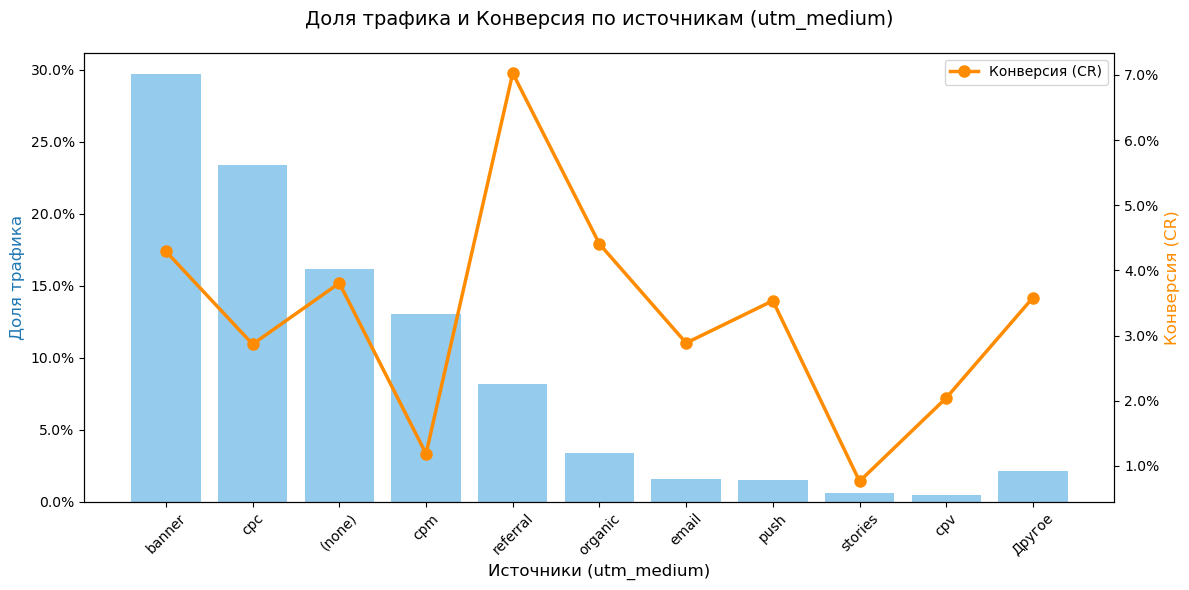

In [90]:
get_cr_and_bar_graph_for_cat(df_t, 'utm_medium')

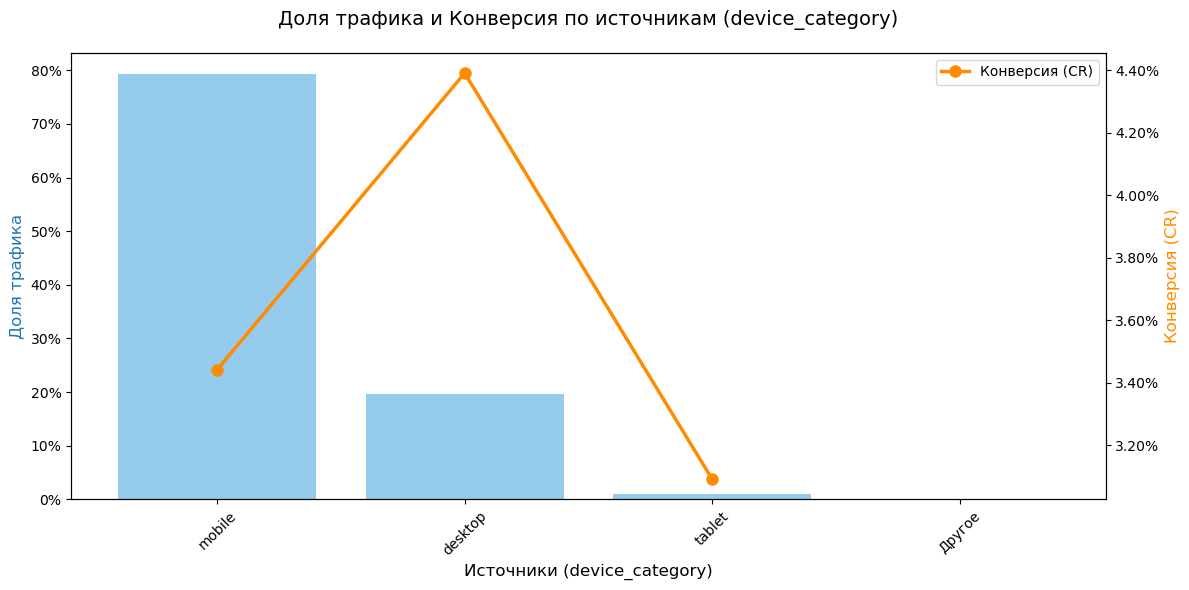

In [91]:
get_cr_and_bar_graph_for_cat(df_t, 'device_category')

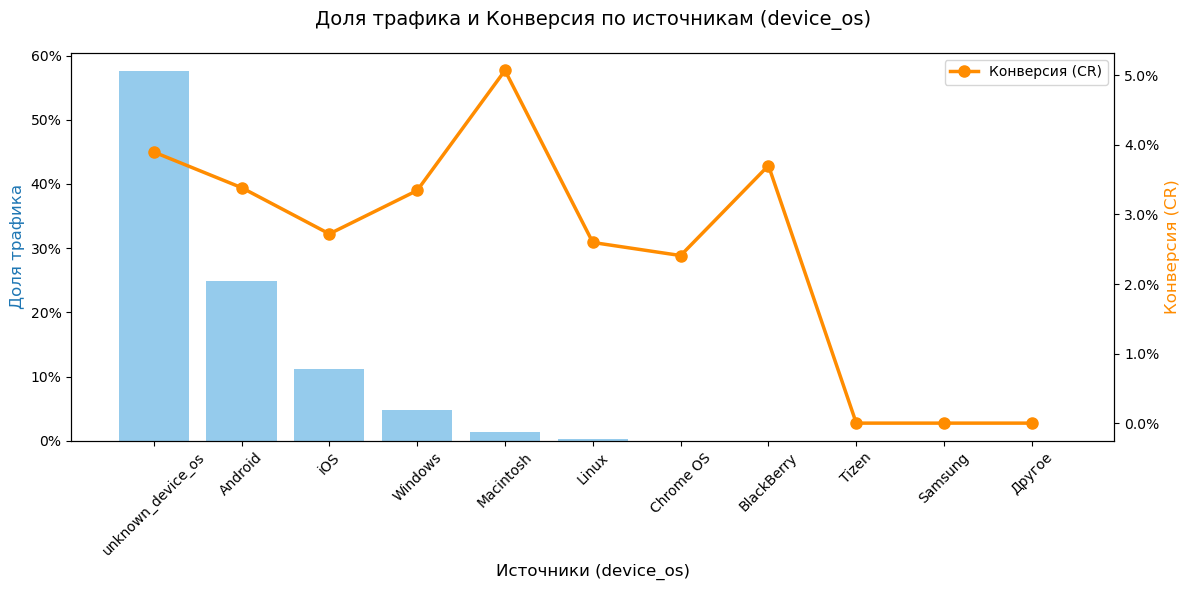

In [92]:
get_cr_and_bar_graph_for_cat(df_t, 'device_os')

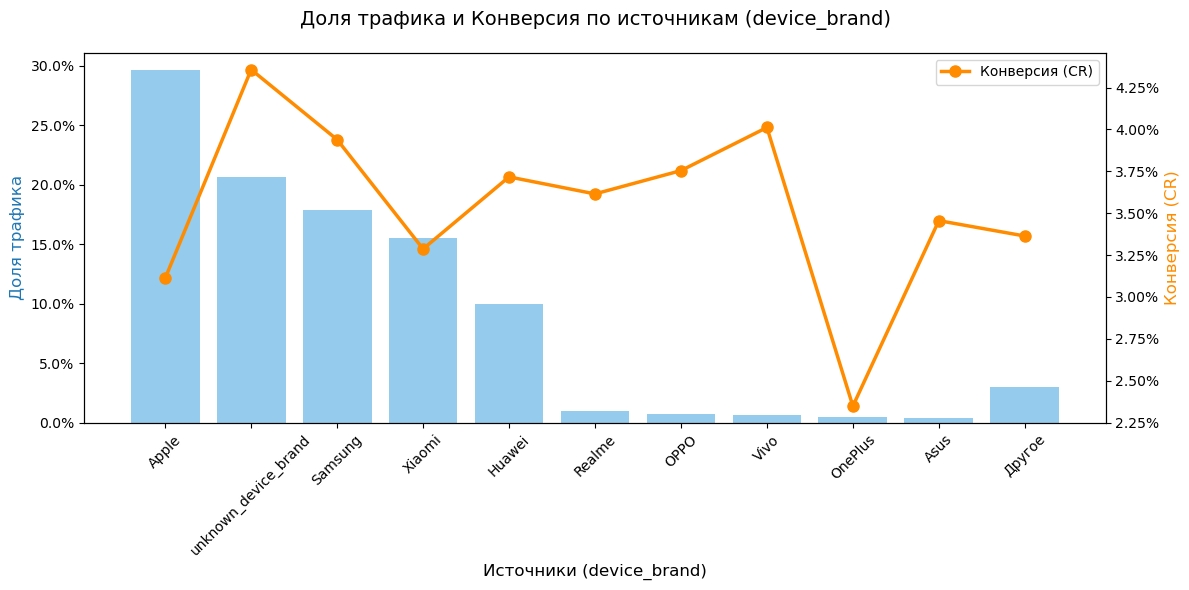

In [93]:
get_cr_and_bar_graph_for_cat(df_t, 'device_brand')

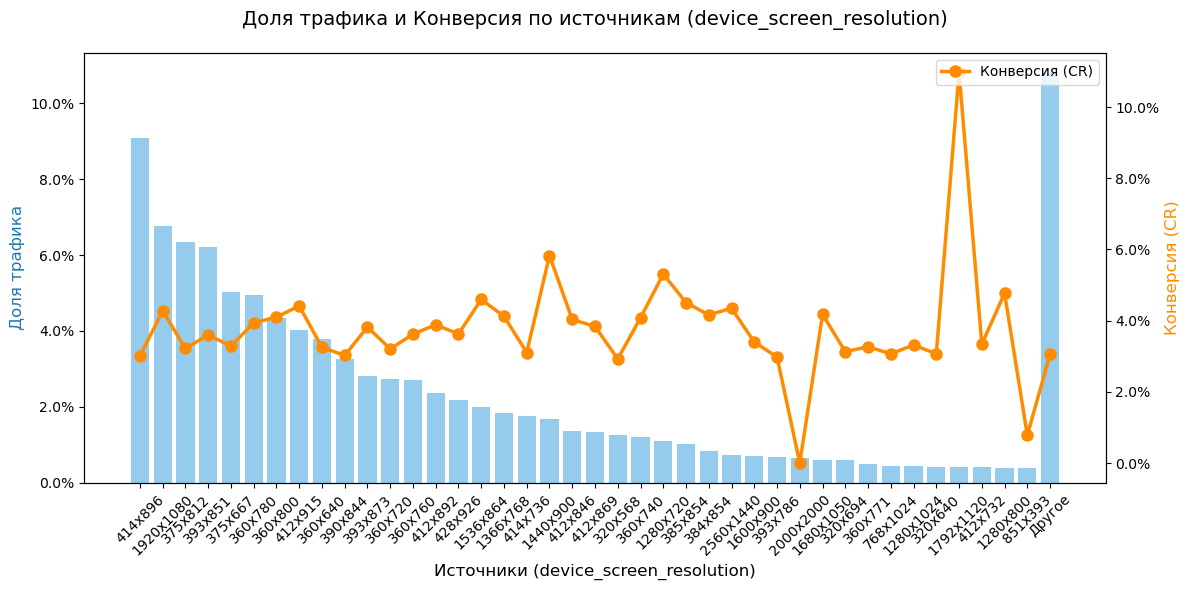

In [94]:
get_cr_and_bar_graph_for_cat(df_t, 'device_screen_resolution', top_n = 40)

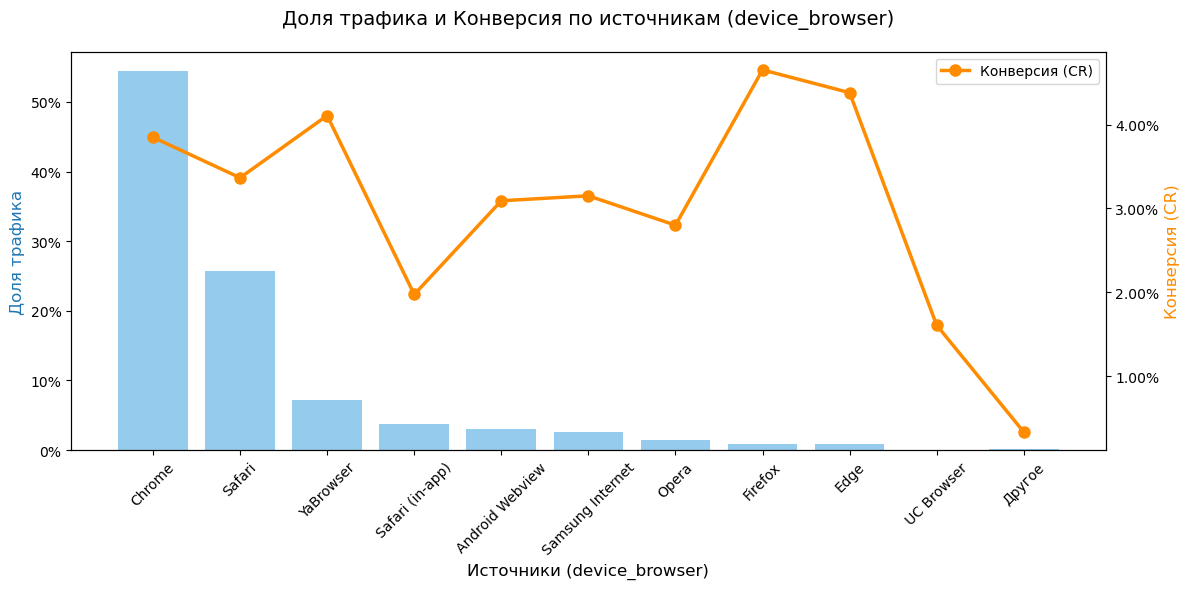

In [95]:
get_cr_and_bar_graph_for_cat(df_t, 'device_browser', top_n = 10)

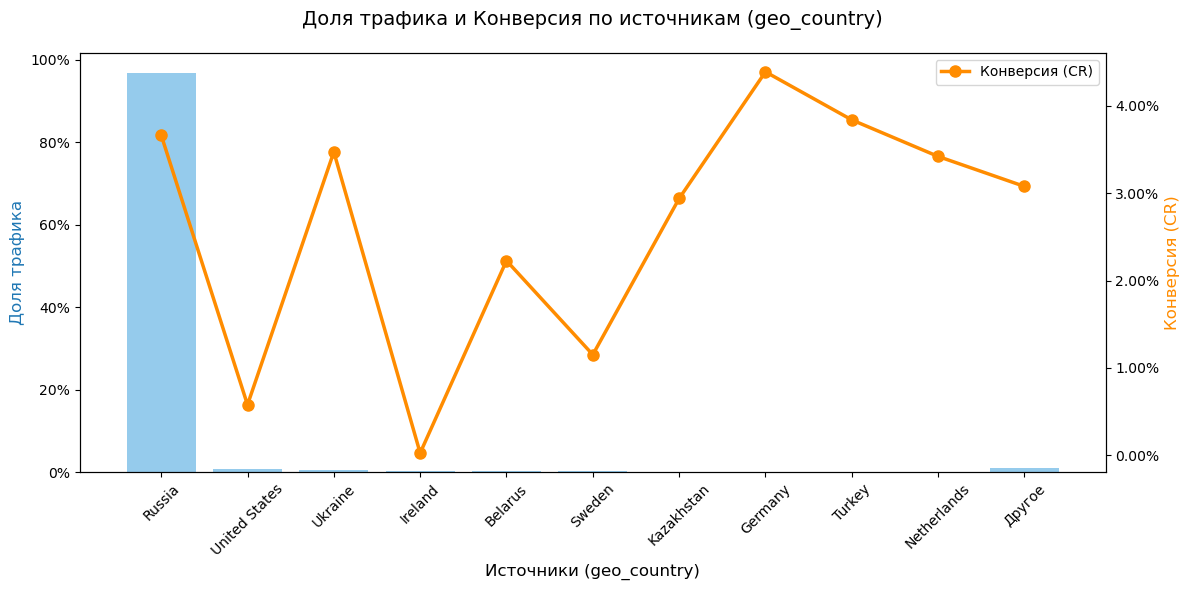

In [96]:
get_cr_and_bar_graph_for_cat(df_t, 'geo_country', top_n = 10)

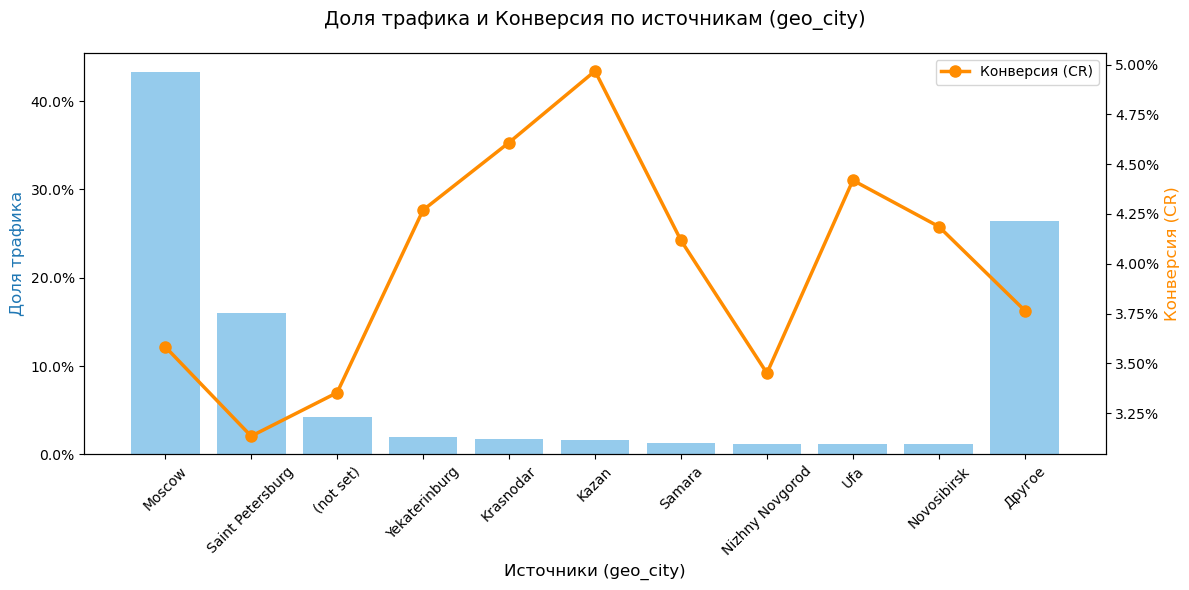

In [97]:
get_cr_and_bar_graph_for_cat(df_t, 'geo_city', top_n = 10)

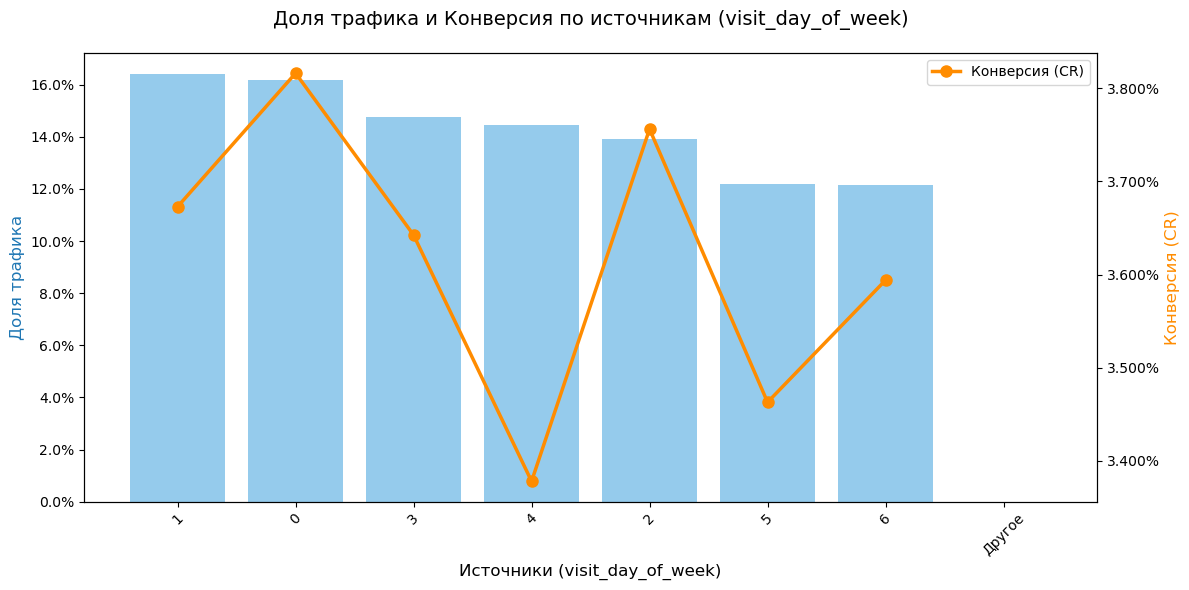

In [98]:
get_cr_and_bar_graph_for_cat(df_t, 'visit_day_of_week', top_n = 10)

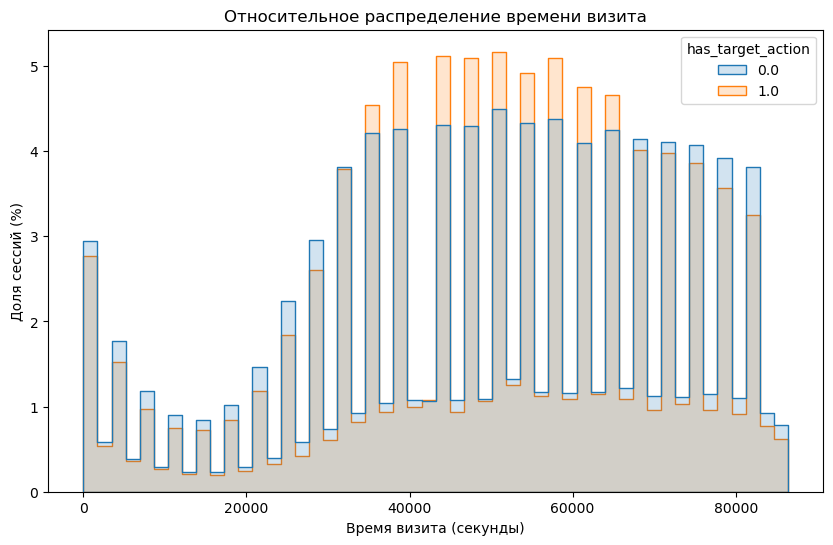

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_t, 
    x='visit_time_sec', 
    hue='has_target_action',
    bins=50, 
    stat='percent',
    common_norm=False,
    alpha=0.2,
    element='step'
)

plt.title('Относительное распределение времени визита')
plt.xlabel('Время визита (секунды)')
plt.ylabel('Доля сессий (%)')

plt.show()

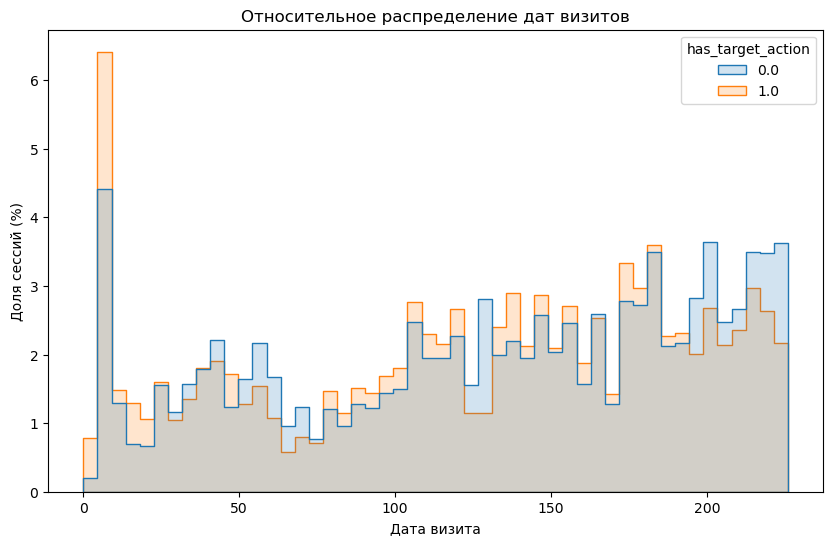

In [101]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_t, 
    x='visit_date_rel', 
    hue='has_target_action',
    bins=50, 
    stat='percent',
    common_norm=False,
    alpha=0.2,
    element='step'
)

plt.title('Относительное распределение дат визитов')
plt.xlabel('Дата визита')
plt.ylabel('Доля сессий (%)')

plt.show()

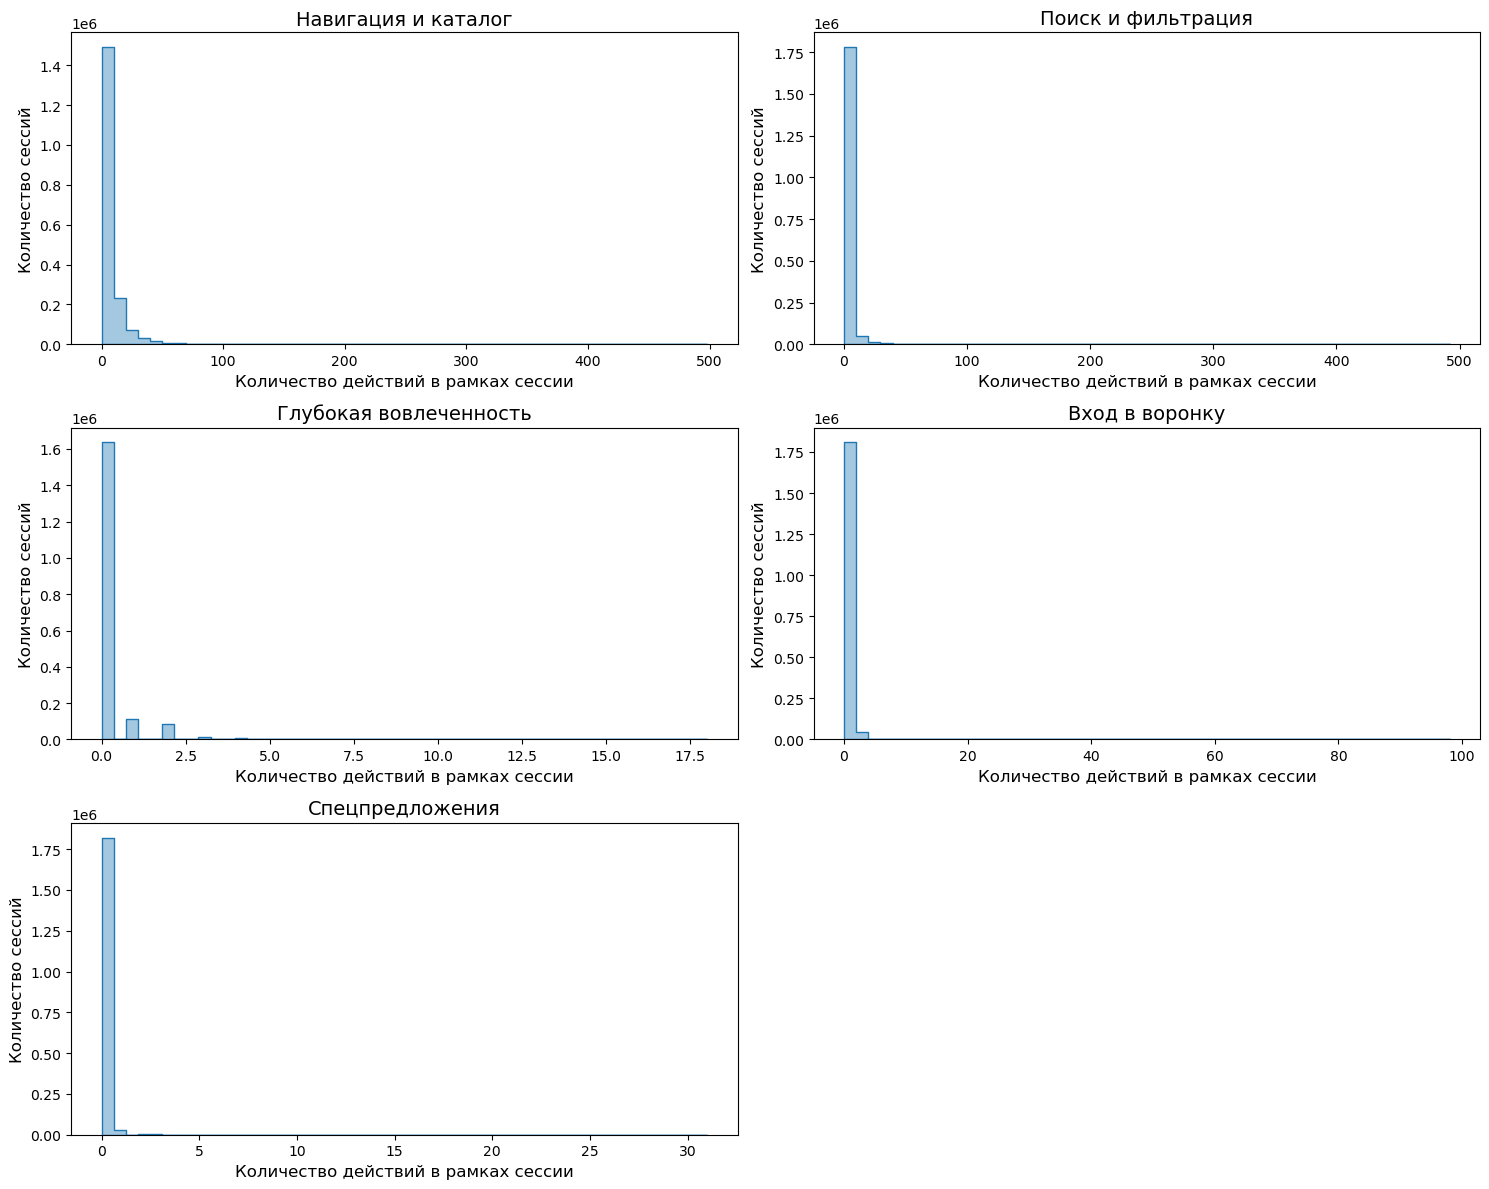

In [102]:
qty_cols = [
    'qty_behavior_exploration', 
    'qty_behavior_filtering', 
    'qty_behavior_engagement', 
    'qty_behavior_funnel_entry', 
    'qty_behavior_promo'
]

labels_map = {
    'qty_behavior_exploration': 'Навигация и каталог',
    'qty_behavior_filtering': 'Поиск и фильтрация',
    'qty_behavior_engagement': 'Глубокая вовлеченность',
    'qty_behavior_funnel_entry': 'Вход в воронку',
    'qty_behavior_promo': 'Спецпредложения'
}

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(qty_cols):
    sns.histplot(
        data=df_t, 
        x=col, 
        ax=axes[i], 
        bins=50, 
        element='step', 
        fill=True, 
        alpha=0.4,
        stat = 'count'
    )
    axes[i].set_title(labels_map[col], fontsize=14)
    axes[i].set_xlabel('Количество действий в рамках сессии', fontsize=12)
    axes[i].set_ylabel('Количество сессий', fontsize=12)

fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

## Обучение модели
Теперь у нас есть табличка df_t информацией о пользовательских сессиях, обогащенная различными фичами которые были заинженерены на предыдущих этапах. Опишем самые важные из них:
- has_target_action (y) - таргет: ключевое поведение пользователя
- hit_number_max - общее кол-во хитов в рамках сессии
- has_behavior_exploration/frac_qty_behavior_exploration - факт и доля событий типа: просмотра карточек автомобилей - ифнормации, фотографий, цены 
- has_behavior_filtering/frac_qty_behavior_filtering - факт и доля событий типа: поиск/фильтрация в поиске
- has_behavior_engagement/frac_qty_behavior_engagement - факт и доля событий типа: энгейджмент с предложением о покупке/конкурентных преимуществах
- has_behavior_funnel_entry/frac_qty_behavior_funnel_entry - факт и доля событий типа: переход в воронку для получения предложения (общение с менеджером, аутентификация в сервисе)
- has_behavior_promo/frac_qty_behavior_promo - факт и доля событий типа: взаимодействие с промо акциями и предложениями
- visit_day_of_week - день недели (Понедельник - 1, Вторник - 2 ...) чтобы учесть сезонность
- seconds_from_last_visit - сколько прошло секунд с предыдущей сессии данного client_id
- found_car_latest - последняя марка+модель автомобиля с которой пользователь взаимодейстовал в рамках сессии
- found_car_brand_latest - последняя марка автомобиля с которой пользователь взаимодействовал в рамках сесиии

In [113]:
df_t.columns

Index(['session_id', 'client_id', 'visit_date', 'visit_time', 'visit_number',
       'utm_source', 'utm_medium', 'utm_campaign', 'utm_adcontent',
       'utm_keyword', 'device_category', 'device_os', 'device_brand',
       'device_model', 'device_screen_resolution', 'device_browser',
       'geo_country', 'geo_city', 'has_target_action', 'hit_number_max',
       'has_behavior_exploration', 'qty_behavior_exploration',
       'has_behavior_filtering', 'qty_behavior_filtering',
       'has_behavior_engagement', 'qty_behavior_engagement',
       'has_behavior_funnel_entry', 'qty_behavior_funnel_entry',
       'has_behavior_promo', 'qty_behavior_promo', 'session_length',
       'found_car_latest', 'found_car_brand_latest', 'visit_time_sec',
       'visit_date_rel', 'timestamp', 'seconds_from_last_visit',
       'frac_qty_behavior_exploration', 'frac_qty_behavior_filtering',
       'frac_qty_behavior_funnel_entry', 'frac_qty_behavior_engagement',
       'frac_qty_behavior_promo', 'visit_day_

### Обоснование выбора модели CatBoost
- В датасете много категориальных признаков с которыми Catboost работает из коробки без необходимости численного энкодинга переменных
- Встроенная обработка пропущенный значений в CatBoost: несмотря на то, что на этапе очистки данных мы поработали с пропущенными значениями. В результате фича инжиниринга и создания новых категориальных переменных, в виду отсутствия в некоторых пользовательских сессиий каких-либо действий в датасете существуют "значимые" пропуски которые полезны для предсказаний

### FeatureSelection Catboost
Очевидно не все созданные и наследованные из изначальных датасетов признаки вообще будут каким-либо образом влиять на предсказание. Более того, обучение на сабсете из слишком большого числа нерелевантных признаков может повредить точности предсказаний.

Проведем фича селекшн при помощи базовой CatBoostClassifier на 200 итераций с max_depth = 6 (с возможностью ранней остановки) и при помощи последовательного исключения на каждой следующей итерации признака составляющего наименьшую важность для модели (через feature_importances) найдем 1) оптимальное кол-во признаков для обучения модели в задаче предсказания наличия has_target_action 2) набор этих оптимальных признаков. Точку "оптимума" будем искать по ROC_AUC скору

In [103]:
X = df_t[[
          'visit_day_of_week', 'visit_number', 'visit_time_sec', 'seconds_from_last_visit',
       'utm_source', 'utm_medium', 'utm_campaign', 'utm_adcontent',
       'utm_keyword', 'device_category', 'device_os', 'device_brand',
       'device_model', 'device_screen_resolution', 'device_browser',
       'geo_country', 'geo_city', 'hit_number_max',
       'has_behavior_exploration', 
       'has_behavior_filtering',
       'has_behavior_engagement', 
       'has_behavior_funnel_entry',
       'has_behavior_promo',
       'frac_qty_behavior_exploration',
       'frac_qty_behavior_filtering',
        'frac_qty_behavior_engagement',
        'frac_qty_behavior_funnel_entry',
       'frac_qty_behavior_promo', 'session_length',
         'found_car_latest', 'found_car_brand_latest']]
y = df_t['has_target_action']

In [105]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [106]:
from sklearn.preprocessing import RobustScaler

numeric_features = [
    'visit_time_sec', 'seconds_from_last_visit',
    'visit_number', 'hit_number_max',
       'frac_qty_behavior_exploration',
       'frac_qty_behavior_filtering',
    'frac_qty_behavior_engagement',
    'frac_qty_behavior_funnel_entry',
       'frac_qty_behavior_promo',
    'session_length'
]

scaler = RobustScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])

binary_features = [
    'has_behavior_exploration', 'has_behavior_filtering', 
    'has_behavior_engagement', 'has_behavior_funnel_entry', 
    'has_behavior_promo'
]

X_train[binary_features] = X_train[binary_features].astype('int8')

In [123]:
from catboost import CatBoostClassifier, Pool, EShapCalcType, EFeaturesSelectionAlgorithm

object_cols = X_train.select_dtypes(include=['object']).columns.tolist()

train_pool = Pool(X_train, y_train, cat_features = object_cols)
valid_pool = Pool(X_test, y_test, cat_features = object_cols)

cboost = CatBoostClassifier(iterations=100, random_seed=42)
summary = cboost.select_features(
    train_pool,
    eval_set=valid_pool,
    features_for_select='0-30',
    num_features_to_select=1,
    steps=4,
    algorithm=EFeaturesSelectionAlgorithm.RecursiveByLossFunctionChange,
    shap_calc_type=EShapCalcType.Regular,
    train_final_model=False,
    logging_level='Silent',
    plot=False
)

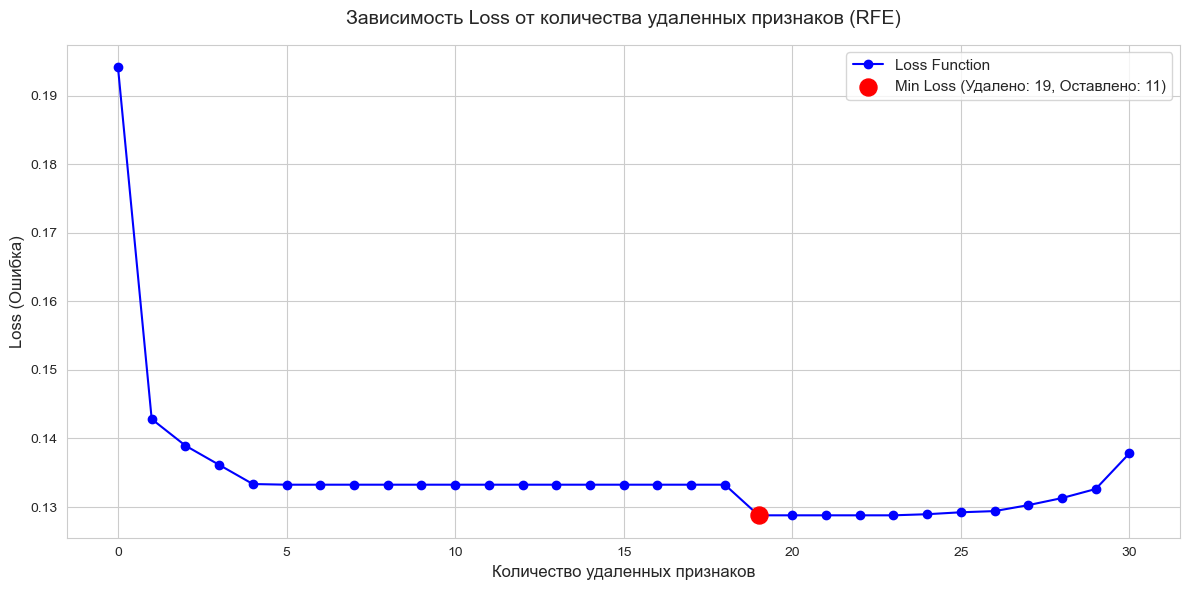


--- ПОСЛЕДОВАТЕЛЬНОСТЬ УСТРАНЕНИЯ ПРИЗНАКОВ ---


,Шаг удаления,Удаленный признак,Loss после удаления
0,1,hit_number_max,0.142824
1,2,visit_number,0.138956
2,3,session_length,0.136153
3,4,has_behavior_funnel_entry,0.133354
4,5,seconds_from_last_visit,0.133258
5,6,visit_day_of_week,0.133258
6,7,visit_time_sec,0.133258
7,8,utm_source,0.133258
8,9,utm_campaign,0.133258
9,10,utm_adcontent,0.133258


In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

loss_values = summary['loss_graph']['loss_values']
removed_counts = summary['loss_graph']['removed_features_count']
eliminated_names = summary['eliminated_features_names']

min_loss_idx = np.argmin(loss_values)
best_removed_count = removed_counts[min_loss_idx]
min_loss = loss_values[min_loss_idx]

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

plt.plot(removed_counts, loss_values, marker='o', linestyle='-', color='b', markersize=6, label='Loss Function')

plt.scatter(best_removed_count, min_loss, color='red', s=150, zorder=5, 
            label=f'Min Loss (Удалено: {best_removed_count}, Оставлено: {len(removed_counts) - 1 - best_removed_count})')

# Оформление
plt.title('Зависимость Loss от количества удаленных признаков (RFE)', fontsize=14, pad=15)
plt.xlabel('Количество удаленных признаков', fontsize=12)
plt.ylabel('Loss (Ошибка)', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

elimination_df = pd.DataFrame({
    'Шаг удаления': range(1, len(eliminated_names) + 1),
    'Удаленный признак': eliminated_names,
    'Loss после удаления': loss_values[1:] 
})

print("\n--- ПОСЛЕДОВАТЕЛЬНОСТЬ УСТРАНЕНИЯ ПРИЗНАКОВ ---")
display(elimination_df)

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import average_precision_score, roc_auc_score

object_cols = X_train.select_dtypes(include=['object']).columns.tolist()

def custom_feature_elimination(X_train, y_train, X_val, y_val, cat_cols, metric='prauc'):
    current_features = list(X_train.columns)
    history = []
    
    print(f"Начинаем отбор из {len(current_features)} признаков. Метрика: {metric.upper()}")
    
    while len(current_features) > 0:
        current_cat_features = [f for f in cat_cols if f in current_features]
        
        model = CatBoostClassifier(
            iterations=200, 
            learning_rate=0.1,
            depth=6,
            random_seed=42,
            verbose=0,
            cat_features=current_cat_features
        )
        
        model.fit(
            X_train[current_features], y_train, 
            eval_set=(X_val[current_features], y_val),
            early_stopping_rounds=20
        )
        
        y_pred_proba = model.predict_proba(X_val[current_features])[:, 1]

        if metric == 'prauc':
            score = average_precision_score(y_val, y_pred_proba) 
        else:
            score = roc_auc_score(y_val, y_pred_proba)
            
        importances = model.get_feature_importance()
        worst_feature_idx = np.argmin(importances)
        worst_feature = current_features[worst_feature_idx]
        
        history.append({
            'features_count': len(current_features),
            'score': score,
            'dropped_feature': worst_feature
        })
        
        current_features.remove(worst_feature)
        if len(current_features) % 5 == 0:
            print(f"Осталось признаков: {len(current_features)} | {metric.upper()}: {score:.4f}")
            
    return pd.DataFrame(history)

In [108]:
rfe_results = custom_feature_elimination(X_train, y_train, X_test, y_test, object_cols, metric='roc_auc')

Начинаем отбор из 31 признаков. Метрика: ROC_AUC
Осталось признаков: 30 | ROC_AUC: 0.7857
Осталось признаков: 25 | ROC_AUC: 0.8109
Осталось признаков: 20 | ROC_AUC: 0.8049
Осталось признаков: 15 | ROC_AUC: 0.7994
Осталось признаков: 10 | ROC_AUC: 0.8048
Осталось признаков: 5 | ROC_AUC: 0.7950
Осталось признаков: 0 | ROC_AUC: 0.6379


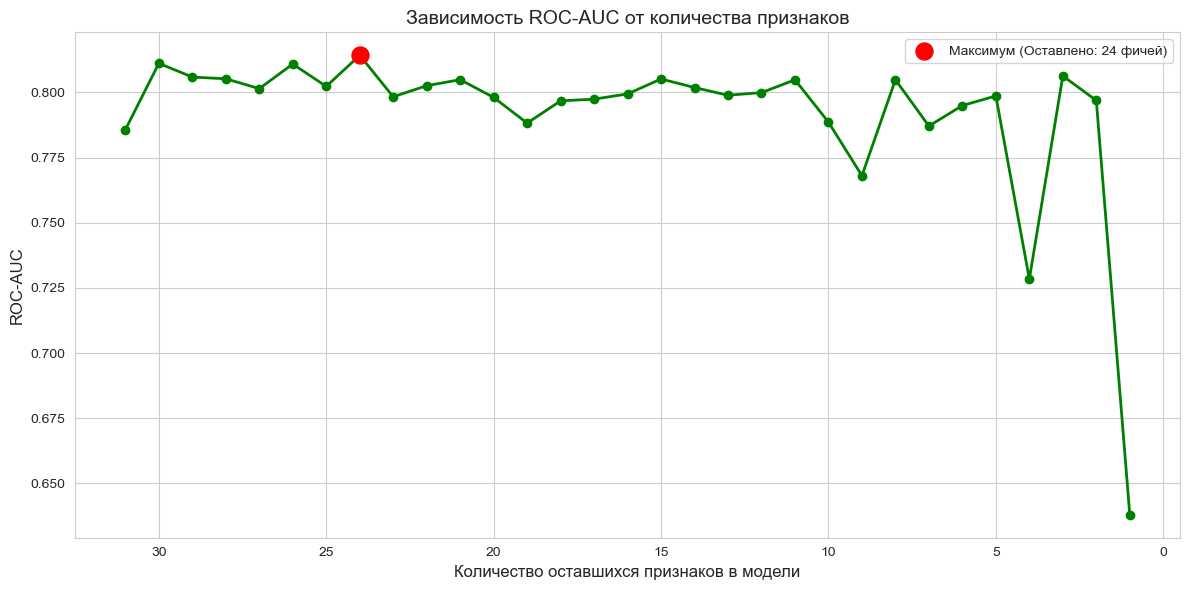


Идеальное количество признаков: 24
Лучший ROC-AUC: 0.8143


,features_count,score,dropped_feature
0,31,0.785695,visit_time_sec
1,30,0.811173,visit_day_of_week
2,29,0.805905,utm_adcontent
3,28,0.805240,utm_keyword
4,27,0.801474,device_brand
5,26,0.810899,device_model
6,25,0.802317,device_screen_resolution
7,24,0.814253,device_category
8,23,0.798333,device_browser
9,22,0.802597,geo_country


In [109]:
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

best_step = rfe_results.loc[rfe_results['score'].idxmax()]

plt.plot(rfe_results['features_count'], rfe_results['score'], marker='o', color='green', linewidth=2)
plt.scatter(best_step['features_count'], best_step['score'], color='red', s=150, zorder=5,
            label=f"Максимум (Оставлено: {best_step['features_count']} фичей)")

plt.gca().invert_xaxis()
plt.title('Зависимость ROC-AUC от количества признаков', fontsize=14)
plt.xlabel('Количество оставшихся признаков в модели', fontsize=12)
plt.ylabel('ROC-AUC', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nИдеальное количество признаков: {best_step['features_count']}")
print(f"Лучший ROC-AUC: {best_step['score']:.4f}")

display(rfe_results)

В результате в оптимуме получили что при заданных параметрах CatBoost оптимально было бы взять в сумме 24 признаков из 31, признаки которые мы дропнули запишем в features_to_drop и не будем использовать для дальнешего тюнинга модели

In [110]:
features_to_drop = rfe_results.head(rfe_results['score'].idxmax())['dropped_feature']

In [111]:
X_train_s = X_train.drop(columns = features_to_drop)
X_test_s = X_test.drop(columns = features_to_drop)

### Подбор гипермараметров

In [113]:
object_cols = X_train_s.select_dtypes(include=['object']).columns.tolist()

param_grid = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'depth': [4, 5, 6, 7],
    'l2_leaf_reg': [1, 3, 5, 7, 9]
}

cboost = CatBoostClassifier(
    iterations=1000,
    early_stopping_rounds=50,
    eval_metric='AUC',
    logging_level='Silent',
    cat_features=object_cols,
    random_state=42
)

grid_search_result = cboost.randomized_search(
    param_grid, 
    X=X_train_s, 
    y=y_train, 
    cv=3,
    n_iter=20,
    plot=True 
)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.
0:	loss: 0.9091722	best: 0.9091722 (0)	total: 3m 22s	remaining: 1h 4m 16s
Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.
1:	loss: 0.9419541	best: 0.9419541 (1)	total: 6m 54s	remaining: 1h 2m 11s
Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.
2:	loss: 0.9349992	best: 0.9419541 (1)	total: 10m 23s	remaining: 58m 54s
Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.
3:	loss: 0.9394020	best: 0.9419541 (1)	total: 13m 44s	remaining: 54m 58s
Metric AUC is not calculated on train by default. To calculate this metric on train, add hints=skip_train~false to metric parameters.
4:	loss: 0.9436953	best: 0.9436953 (

In [121]:
grid_search_result['params']

{'depth': 7, 'learning_rate': 0.2, 'l2_leaf_reg': 7}

In [131]:
best_cboost = CatBoostClassifier(iterations = 1000,
    early_stopping_rounds=50,
                                 depth = 7,
                                learning_rate = 0.2,
                                 l2_leaf_reg = 7,

    eval_metric='AUC',
                                     verbose=100,
    # cat_features=object_cols,
    random_state=42)

In [132]:
best_cboost.fit(X_train_s, y_train, cat_features = object_cols)

0:	total: 543ms	remaining: 9m 2s
100:	total: 40.4s	remaining: 6m
200:	total: 1m 20s	remaining: 5m 21s
300:	total: 2m	remaining: 4m 40s
400:	total: 2m 44s	remaining: 4m 5s
500:	total: 3m 26s	remaining: 3m 25s
600:	total: 4m 7s	remaining: 2m 44s
700:	total: 4m 48s	remaining: 2m 3s
800:	total: 5m 30s	remaining: 1m 22s
900:	total: 6m 11s	remaining: 40.8s
999:	total: 6m 51s	remaining: 0us


CatBoostClassifier(depth=7, early_stopping_rounds=50, eval_metric='AUC', iterations=1000, l2_leaf_reg=7, learning_rate=0.2, random_state=42, verbose=100)

In [133]:
y_pred = best_cboost.predict(X_test_s)

In [134]:
best_cboost.predict_proba(X_test_s)[:, 1]

array([0.45038635, 0.12599584, 0.32437814, ..., 0.24690267, 0.00062329,
       0.05178424], shape=(372009,))

In [135]:
from sklearn.metrics import roc_auc_score, auc
from sklearn.metrics import classification_report

print(f'ROC-AUC скор модели: {roc_auc_score(y_test, best_cboost.predict_proba(X_test_s)[:, 1]):.3f}')
print(classification_report(y_test, y_pred))

ROC-AUC скор модели: 0.737
              precision    recall  f1-score   support

         0.0       0.98      0.89      0.93    358586
         1.0       0.13      0.41      0.19     13423

    accuracy                           0.87    372009
   macro avg       0.55      0.65      0.56    372009
weighted avg       0.95      0.87      0.91    372009



- По результатам фита получили модель которая хорошо предсказывает отсутствие целевого действия по прихнакам польозовательского захода в сервис SberAuto (Precision для предсказания меток класса 0 = 0.98 и recall = 0.89).
- При это из-за диспрапорции в числе наблюдений 0 vs 1 и большой доли "мусорных сессий" модель предсказывает метки класса 1 с худшей точностью. Однако recall все еще высокий и указывает на то, что в случае, когда модели встречается "настоящий лид" (была CR в целевое) она распознает его верно с вероятностью 0.41.

### Интерпретация результатов модели

In [136]:
import shap

shap.initjs()

explainer = shap.TreeExplainer(best_cboost)
shap_values = explainer.shap_values(X_test_s)

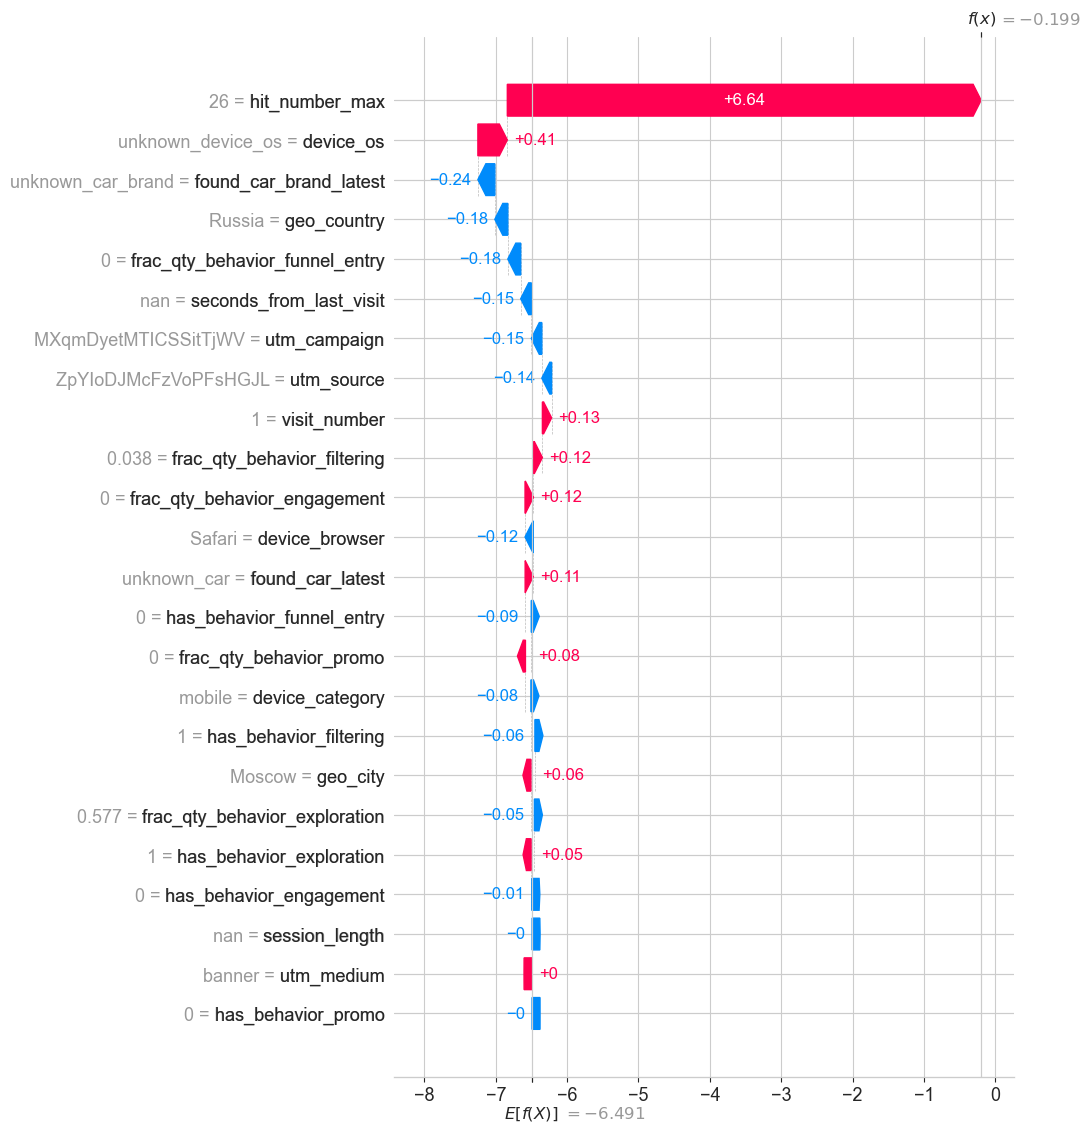

In [137]:
shap.plots.waterfall(explainer(X_test_s)[0], max_display=30)

Как читать график Шапов ниже:
- По Оси X (Shap-Value) - насколько в + или - фича влияет на вероятность целевого действия внутри визита (CR)
- По Оси Y - признаки использованные для обучения в модели
- Цвет: Красный - высокое значение признака (например hit_number_max = 200), Синий - низкое значение признака (например hit_number_max = 0)
- Distribution: Плотность наблюдений внутри данных использованных для предсказания. Широкий интервал - много наблюдений, узкий интервал - мало наблюдений (пользовательских сесссий)

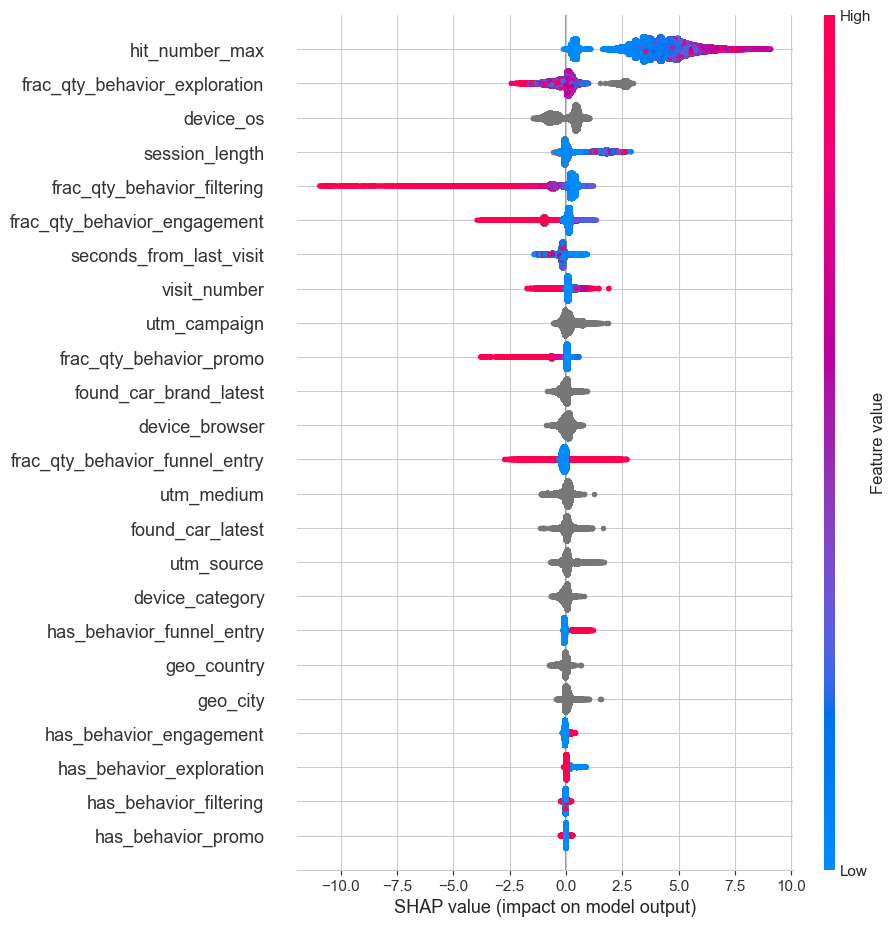

In [138]:
shap.plots.beeswarm(explainer(X_test_s), max_display = 31)

**Интерпретация фичей в модели**
Прочитаем график c SHAP-values для фичей в обученной нами модели
- **Важно сколько пользователь проводит время внутри сервиса.**: Сильно влияют на предсказание конверсии в целевое действие признаки "Кол-во пользовательских действий в рамках сессии" (hit_number_max) и "Длина пользовательской сессии" (seession_length). 
 - **Windowshopping вредит**: Пользователи которые приходят "поглазеть" и часто пользуются фильтрами, смотрят больше картчек автомобилеей в доле от времени проведенного внутри сервиса (frac_quantity_behaviour_filtering и frac_quantity_behaviour_exploration) реже конвертируются в целевое действие. Об этом говорит длинный красный хвост (высокое значение метркии) в отрицательной зоне SHAP-value
- **Раньше возвращается - чаще покупает**: В среднем чем ближе последующая сессии посещения сервиса была к предыдущей (seconds_from_last_visit) тем с большей вероятностью пользователь сконвертируется в целевое действие. Об этом говорит удлиненный правый хвост SHAP-value в котором сконцентрировано больше маленьких (синих) значений seconds_from_last_visit
- **Частые заходы на сервис могут быть и плохим и хорошим знаком для конверсии**: Интересно, что частые заходы на сервис (признак visit_number) связаны как с повышенной веряотоностью покупки в отдельную сессию, так и с пониженной - распределение имеет красные хвосты по ту и другую сторону от нуля на графике распределения SHAP-values. Эта особенность может быть связана с тем, что много визитов совершают боты, которые не конвертятся в целевые действия (просто скрейпят карточки автомобилей и предложения), при этом много визитов могут совершать и настоящие пользователи, заряженные на покупку, но еще неуверенные в своем выборе в рамках самых первых визитов.
- Факт наличия взаимодействия с промо акциями повышает веряотность конверсии в целевое действие в рамках отдельной сессии (признак has_behavior_promo), но при этом высокая доля событий взаимодействия с промо frac_has_behavior_promo напротив отрицательно ассоциируется с вероятностью конверсии в целевое действие. Дело в том, что разнообразных промо событий мало и пользователи, доля промо событий которых высока, с большей вероятностью имеют короткие пользовательские сессии, в рамках которых они просто напросто бросили воронку слишком рано
- **Менее "разборчивые" пользователи лучше покупают** Как только пользователь входит в воронку (has_behaviour_funnel_entry - ему предлагаются повзаимодействовтаь в чатах с менеджерами, он видит форму аутентификации или ввода номера) вероятность конверсии в целевое действие достаточно значимо возрастает. При этом позитивное влияние оказывает и признак frac_qty_behaviour_funnel_entry. Это означает что менее "разборчивые" пользователи меньше времени проводящие на этапе просмотра карточек товара, взаимодействиями с фильтрами проходят по воронке и конвертятся в целевые действия лучше, что вполне логично

### Сохраняем модель

In [139]:
best_cboost.save_model('catboost_model_sber.cbm')